# Titanic Survival Prediction

项目参考：[Advanced Feature Engineering](https://www.kaggle.com/code/gunesevitan/titanic-advanced-feature-engineering-tutorial/notebook)

## 明确问题

- 目标：预测乘客是否幸存（Survived=0/1）
- 二分类问题（classification）
- 评价指标：准确率（Accuracy）、F1-score、AUC-ROC 等

## 获取数据

数据来自 Kaggle Titanic 数据集：
- train.csv（有标签）
- test.csv（无标签，需要提交预测结果）
- truth.csv（测试集的标签）

In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn.objects as so
from matplotlib.pyplot import figure
from statsmodels.tsa.vector_ar.var_model import test_normality
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_curve, auc, roc_auc_score
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report

from scipy.stats import trim_mean
from scipy.stats import median_abs_deviation
from scipy.stats import spearmanr
import scipy


首先导入数据：


In [2]:
train = pd.read_csv("titanic/train.csv")
test = pd.read_csv("titanic/test.csv")
y_test = pd.read_csv("titanic/truth.csv")

train.name = 'Training Set'
test.name = 'Test Set'

print(f"训练集结构:{train.shape}")
print(f"测试集结构:{test.shape}")
print(f"测试集标签的结构:{y_test.shape}")
print(f"训练集的列名:{train.columns}")
print(f"测试集列名:{test.columns}")

训练集结构:(891, 12)
测试集结构:(418, 11)
测试集标签的结构:(418, 2)
训练集的列名:Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')
测试集列名:Index(['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')


In [3]:
# 分割训练集
train, y_train = train.drop('Survived', axis=1), train[['PassengerId','Survived']]

# 将训练集和测试集进行拼接
total = pd.concat([train, test], ignore_index=True)
print(f"总数据集的结构:{total.shape}")

total.name = 'All Set'
total.head()

总数据集的结构:(1309, 11)


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
# 了解数据集
total.describe()

,PassengerId,Pclass,Age,SibSp,Parch,Fare
count,1309.000000,1309.000000,1046.000000,1309.000000,1309.000000,1308.000000
mean,655.000000,2.294882,29.881138,0.498854,0.385027,33.295479
std,378.020061,0.837836,14.413493,1.041658,0.865560,51.758668
min,1.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,328.000000,2.000000,21.000000,0.000000,0.000000,7.895800
50%,655.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,982.000000,3.000000,39.000000,1.000000,0.000000,31.275000
max,1309.000000,3.000000,80.000000,8.000000,9.000000,512.329200


利用`describe`获取数据的整体统计信息:
1. Survived：本数据集的target，二元分类数据。key = 0, 1
2. PassengerId：乘客的身份id 唯一值 离散型数据
3. Pclass：乘客的Ticket class（票务等级）， key = 1， 2，3 （一等，二等，三等）
4. Name：乘客的姓名， 字符串类型 unstructured data
5. Sex：乘客的性别，二元分类数据，key = male, female
6. Age：年龄，数值型数据，连续型数据
7. Sibsp：泰坦尼克号上的兄弟姐妹/配偶数量， 数值型数据，离散型数据
8. Parch：泰坦尼克号上父母/孩子的数量，数值型数据，离散型数据
9. Ticket：车票号码
10. Fare：票价，数值型数据，连续型数据
11. Cabin：客舱号 /房间号
12. Embarked：起运港，分类数据。key = S, C, Q

**总结：**
1. 离散值数据有：Sibsp, Parch, Ticket
2. 分类数据有：Pclass, Sex, Cabin, Embarked
3. 具有唯一的数据有：PassengerId, Name
4. 连续性数据有：Age, Fare

In [5]:
total.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Pclass       1309 non-null   int64  
 2   Name         1309 non-null   object 
 3   Sex          1309 non-null   object 
 4   Age          1046 non-null   float64
 5   SibSp        1309 non-null   int64  
 6   Parch        1309 non-null   int64  
 7   Ticket       1309 non-null   object 
 8   Fare         1308 non-null   float64
 9   Cabin        295 non-null    object 
 10  Embarked     1307 non-null   object 
dtypes: float64(2), int64(4), object(5)
memory usage: 112.6+ KB


由information得到，数据中具有缺失值的特征有：Age, Fare, Cabin, Embarked

## 探索性数据分析（EDA）

### 缺失值

从第一部分已经得知，数据中有缺失值的特征有：Age, Fare, Cabin, Embarked

进一步地分析在训练集和测试集中有缺失值的特征

从结果可得：
- 训练集（train）：Age, Cabin, Embarked有缺失值
- 测试集（test）：Age, Fare, Cabin 有缺失值

首先分析有缺失值的特征

In [6]:
# 训练集的特征信息
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Pclass       891 non-null    int64  
 2   Name         891 non-null    object 
 3   Sex          891 non-null    object 
 4   Age          714 non-null    float64
 5   SibSp        891 non-null    int64  
 6   Parch        891 non-null    int64  
 7   Ticket       891 non-null    object 
 8   Fare         891 non-null    float64
 9   Cabin        204 non-null    object 
 10  Embarked     889 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 76.7+ KB


In [7]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


#### Age

In [8]:
# 缺失值数量
null_values = total['Age'].isnull().sum()
print(f"Age缺失值数量:{null_values}")

train_null_values = train['Age'].isnull().sum()
test_null_values = test['Age'].isnull().sum()

print(f"训练集缺失值数量:{train_null_values}")
print(f"测试集缺失值数量:{test_null_values}")

Age缺失值数量:263
训练集缺失值数量:177
测试集缺失值数量:86


计算数据的集中趋势和离散程度

In [9]:
mean = total['Age'].mean()
tmean = trim_mean(total['Age'].dropna(), 0.1)
median = total['Age'].median()
std = total['Age'].std()
# 中位数绝对偏差
mad = median_abs_deviation(total['Age'].dropna())
# 四分位距
iqr = total['Age'].quantile(0.75)-total['Age'].quantile(0.25)
# 百分位数
per = total['Age'].quantile([0.25,0.50,0.75])

print(f"Age平均值为:{mean:.2f}")
print(f"Age切尾平均值:{tmean:.2f}")
print(f"中位数:{median}")
print(f"标准差:{std:.2f}")
print(f"中位数平均偏差:{mad:.2f}")
print(f"四分位距:{iqr:.2f}")
print("百分位数:")
print(per)

Age平均值为:29.88
Age切尾平均值:29.39
中位数:28.0
标准差:14.41
中位数平均偏差:8.00
四分位距:18.00
百分位数:
0.25    21.0
0.50    28.0
0.75    39.0
Name: Age, dtype: float64


探索Age的数据分布，可以从Age的箱线图看出，最小值约为0岁，最大值约为80岁，中位数为28岁，25百分位数为21岁，75百分位数为39岁。其中超出65岁左右的为异常值，数据中有一定数量的异常值，可以找出这些异常值。

<Axes: >

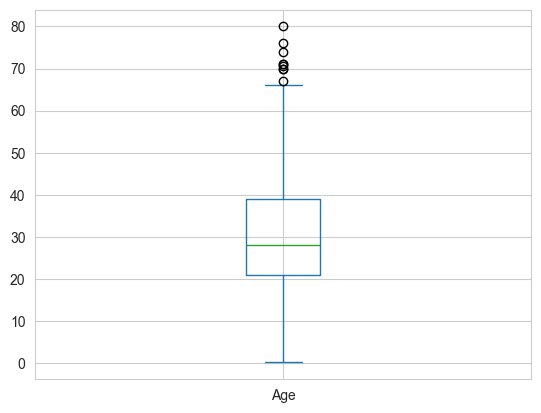

In [10]:
# Age的箱线图
total['Age'].plot.box()

In [11]:
# Age 频数表
ages = pd.cut(total['Age'], bins=8)
ages.value_counts(sort=False).reset_index(name='counts')

,Age,counts
0,"(0.0902, 10.149]",86
1,"(10.149, 20.128]",162
2,"(20.128, 30.106]",361
3,"(30.106, 40.085]",210
4,"(40.085, 50.064]",132
5,"(50.064, 60.043]",62
6,"(60.043, 70.021]",27
7,"(70.021, 80.0]",6


Text(0.5, 0, 'Age')

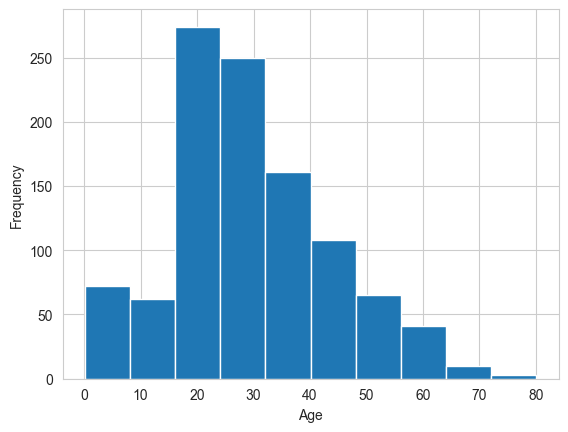

In [12]:
# 绘制Age直方图
ax = total['Age'].plot.hist()
ax.set_xlabel("Age")

Age的直方图显示Age并不是完全的正态分布，我们要更精确填充缺失值应该使用中位数。但是直接使用全数据集的中位数，仍然不够精确。我们可以进一步探索数据集中其他列与Age的相关性

In [13]:
age_corr = total.corrwith(total['Age'], numeric_only=True)
age_corr

PassengerId    0.028814
Pclass        -0.408106
Age            1.000000
SibSp         -0.243699
Parch         -0.150917
Fare           0.178740
dtype: float64

对只有数值的特征计算其与Age的相关程度，其中Pclass与Age相关程度相对较高。除此以外，仍有其他字符串数据未能计算与Age之间的联系，其中Sex可以作为Age的分组，进一步探索性别与年龄之间的联系

In [14]:
null_index = total[total['Age'].isnull()].index

In [15]:
age_class_sex = total.groupby(['Pclass','Sex'])['Age'].median().reset_index(name='median_age')
age_class_sex

,Pclass,Sex,median_age
0,1,female,36.0
1,1,male,42.0
2,2,female,28.0
3,2,male,29.5
4,3,female,22.0
5,3,male,25.0


为了更清楚地展示不同组之间的年龄差异，对其进行可视化。男性的中位数年龄总比女性偏大，但是随着票务等级的降低，中位年龄也呈降低趋势。最终，使用不同票务等级和性别组的中位数对年龄进行分组填充。

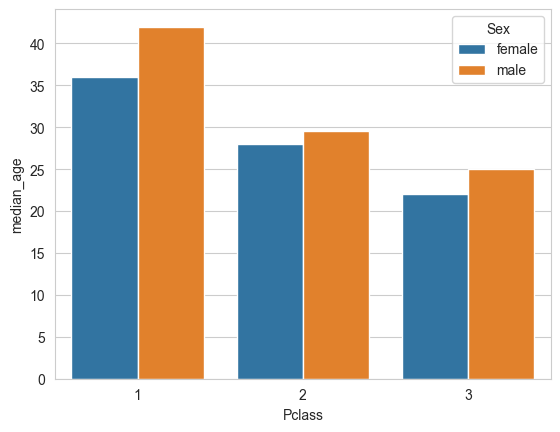

In [16]:
sns.barplot(data=age_class_sex, x='Pclass', y='median_age', hue='Sex')
plt.show()

In [17]:
# 对缺失值进行填充
total['Age'] = total.groupby(['Pclass','Sex'], dropna=False)['Age'].transform(lambda x: x.fillna(x.median()))
print(f"Age缺失值:{total['Age'].isnull().sum()}")

Age缺失值:0


In [18]:
total.loc[null_index,'Age']

5       25.0
17      29.5
19      22.0
26      25.0
28      22.0
        ... 
1299    22.0
1301    22.0
1304    25.0
1307    25.0
1308    25.0
Name: Age, Length: 263, dtype: float64

#### Embarked

起运港：key = S, C, Q

首先查看起运港的缺失值，Embarked这一列有两个缺失值，可以直接查看这两行，看看数据有什么共同点

In [19]:
embarked_null = total['Embarked'].isnull().sum()
print(f"Embarked缺失值数量:{embarked_null}")

Embarked缺失值数量:2


这两条数据的共同点是：这两人都是女性，且都为一等舱乘客，她们的票价，舱号（B28）都是相同的。因此我们可以看看其他相同舱号的乘客大多从哪个起运港出发的。

In [20]:
total[total['Embarked'].isnull()]

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
61,62,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN
829,830,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN


查看B28舱号的其他游客时发现，B28舱号只有这两位缺失了Embarked游客。因此退一步，查看舱号开头为B2的乘客。
一共可以筛选出8条舱号开头为B2的乘客，除了缺失了Embarked值的两位游客，其他都是从S港口出发的，其中大部分也为女性。因此我们推测B28的两位乘客也是从S港口出发的。

In [21]:
b28 = total[(total['Cabin'].fillna('').str.startswith('B28'))]
b2 = total[(total['Cabin'].fillna('').str.startswith('B2'))]
print(f"多数B2舱的乘客的起运舱口:{b2['Embarked'].mode()}")
b2

多数B2舱的乘客的起运舱口:0    S
Name: Embarked, dtype: object


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
61,62,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.00,B28,NaN
540,541,1,"Crosby, Miss. Harriet R",female,36.0,0,2,WE/P 5735,71.00,B22,S
690,691,1,"Dick, Mr. Albert Adrian",male,31.0,1,0,17474,57.00,B20,S
745,746,1,"Crosby, Capt. Edward Gifford",male,70.0,1,1,WE/P 5735,71.00,B22,S
781,782,1,"Dick, Mrs. Albert Adrian (Vera Gillespie)",female,17.0,1,0,17474,57.00,B20,S
829,830,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.00,B28,NaN
1196,1197,1,"Crosby, Mrs. Edward Gifford (Catherine Elizabe...",female,64.0,1,1,112901,26.55,B26,S
1281,1282,1,"Payne, Mr. Vivian Ponsonby",male,23.0,0,0,12749,93.50,B24,S


In [22]:
# 对缺失值进行填充:
total['Embarked'] = total['Embarked'].fillna('S')
print(f"Embarked缺失值数量:{total['Embarked'].isnull().sum()}")

Embarked缺失值数量:0


#### Fare

In [23]:
fare_null_values = total['Fare'].isnull().sum()
print(f"Fare缺失值数量:{fare_null_values}")

Fare缺失值数量:1


Fare列的缺失值数量为1，可以直接查看缺失值的数据。通过查看数据我们发现，该乘客为男性，坐在三等舱，起运港为S，船上没有家属，年龄在60岁以上。为了判断票价与其他特征的联系，进一步地使用斯皮尔曼方法计算相关系数。

In [24]:
total[total['Fare'].isnull()]

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1043,1044,3,"Storey, Mr. Thomas",male,60.5,0,0,3701,NaN,NaN,S


通过计算相关系数得到，票价与票务等级（Pclass）有强烈负相关，除此之外还与Sibsp和Parch有微弱的正相关。我们再假设票价与起运港也有一定关系。根据这几个特征，我们筛选出与该乘客相似的乘客所花的票钱，最后取中位数。

In [25]:
total.corrwith(total['Fare'], numeric_only=True, method='spearman')

PassengerId   -0.003583
Pclass        -0.709019
Age            0.218694
SibSp          0.445566
Parch          0.400301
Fare           1.000000
dtype: float64

In [26]:
total.groupby(['Embarked'])['Fare'].median()

Embarked
C    28.51875
Q     7.75000
S    13.00000
Name: Fare, dtype: float64

In [27]:
cabin_fare = total[(total['Pclass']==3)&(total['Embarked']=='S')&(total['SibSp']==0)&(total['Parch']==0)]
print(f"票价中位数为:{cabin_fare['Fare'].median()}")

票价中位数为:7.8958


In [28]:
# 对缺失值进行填充
total['Fare'] = total['Fare'].fillna(cabin_fare['Fare'].median())

#### Cabin

Cabin是客舱号，在数据集中Cabin的缺失值较多。缺失的Cabin数量大约有总数据的77.46%。一般如此多的缺失数量我会想忽略这个特征，但是Cabin的第一个字母是指客舱所在的甲板位置，不同的区域可能存活率也不同
![alt text](https://vignette.wikia.nocookie.net/titanic/images/f/f9/Titanic_side_plan.png/revision/latest?cb=20180322183733)

客舱号所在的甲板根据乘客的等级进行分割，假设将缺失值全部填充为M


In [29]:
cabin_null_values = total['Cabin'].isnull().sum()
print(f"Cabin的缺失值数量:{cabin_null_values}")

null_ratio = round(100*cabin_null_values/len(total),2)
print(f"占比:{null_ratio}%")

Cabin的缺失值数量:1014
占比:77.46%


- A和B以及C甲板只有一等舱的乘客
- D甲板有一等舱和二等舱的乘客
- E甲板有所有等级的乘客
- F甲板有二等舱和三等舱的乘客
- G甲板只有三等舱的乘客
- 除此之外T甲板只有一个乘客，且是一等舱的

In [30]:
total['Deck'] = total['Cabin'].apply(lambda x: 'M' if pd.isna(x) else x[0])

pclass_cabin = total.groupby(['Deck','Pclass'])['PassengerId'].count().reset_index(name='count')
pclass_cabin['total'] = pclass_cabin.groupby('Deck')['count'].transform('sum')
pclass_cabin['ratio'] = round(100*pclass_cabin['count']/pclass_cabin['total'],2)
pclass_cabin['Pclass'] = pclass_cabin['Pclass'].astype('category')
pclass_cabin

,Deck,Pclass,count,total,ratio
0,A,1,22,22,100.00
1,B,1,65,65,100.00
2,C,1,94,94,100.00
3,D,1,40,46,86.96
4,D,2,6,46,13.04
5,E,1,34,41,82.93
6,E,2,4,41,9.76
7,E,3,3,41,7.32
8,F,2,13,21,61.90
9,F,3,8,21,38.10


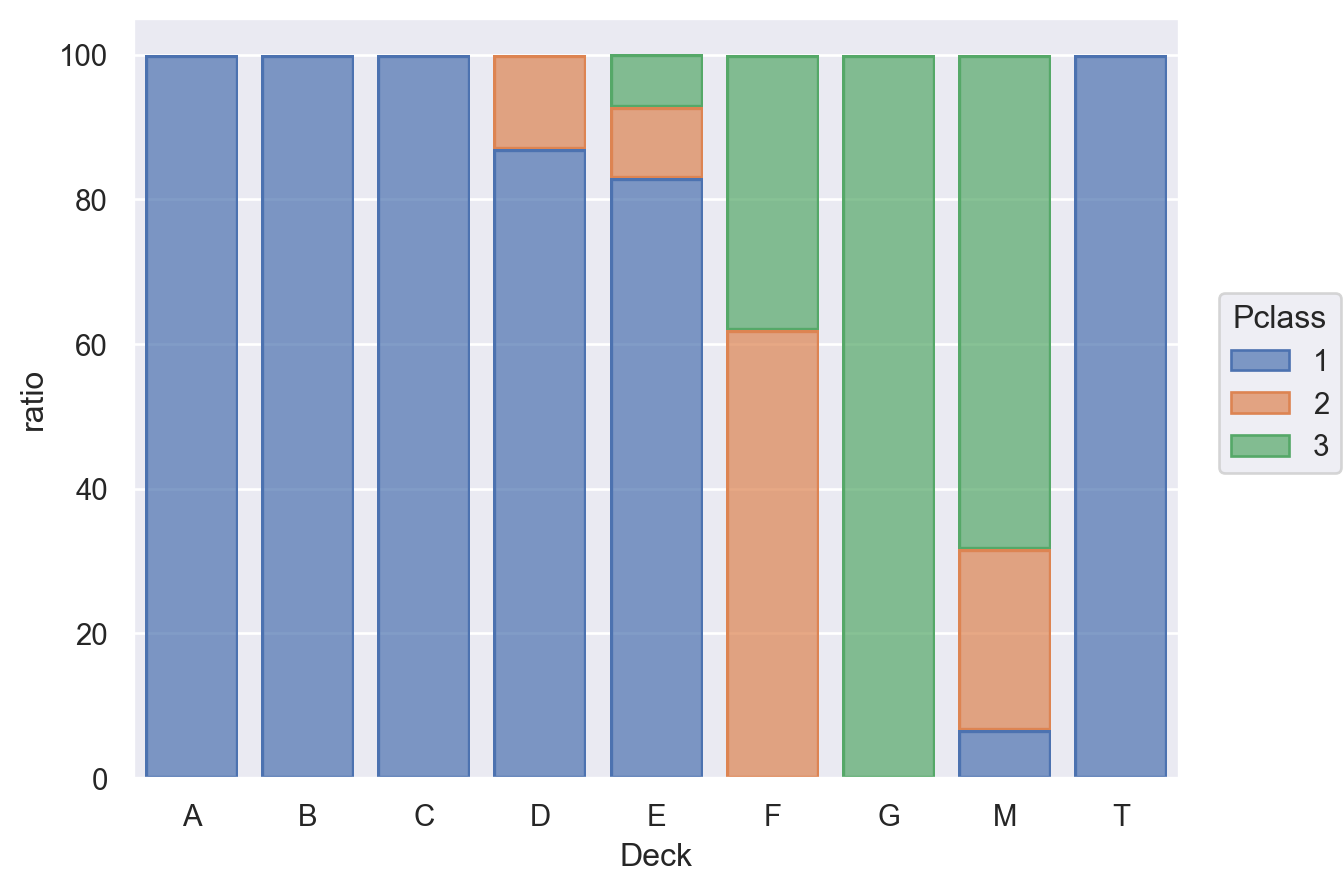

In [31]:
so.Plot(pclass_cabin, x="Deck",y='ratio', color="Pclass").add(so.Bar(), so.Stack())

- 其中A, B, C有100%的一等舱乘客
- D甲板中有86.96%的一等舱乘客和13.04%的二等舱乘客
- E甲板中有83%的一等舱乘客和9.76%的二等舱乘客以及7.32%的三等舱乘客。
- F甲板中有62%的二等舱乘客和38%的三等舱乘客。
- G甲板有100%的三等舱乘客

计算生存率和甲板位置的相关关系, 可以得到类似于协方差矩阵的皮尔逊关系系数矩阵。得到甲板位置与Survived之间有微弱负相关的线性关系。但这不能代表两者之间没有关系，因为两者之间可能是非线性的关系。进一步可以对甲板进行分组，计算每一组的生存率。由于T甲板处只有一个值，且其属于Pclass1，可以将其移到甲板A。

In [32]:
total.loc[total[total['Deck']=='T'].index,'Deck']='A'

In [33]:
y = pd.concat([y_train, y_test]).reset_index(drop=True)
codes = np.arange(9)
categories = sorted(total['Deck'].unique())
mapping = dict(zip(categories, codes))
deck_code = total['Deck'].apply(lambda x: mapping[x])
corrcoef = deck_code.corr(y['Survived'])
print(f"皮尔逊相关系数为:{corrcoef:.3f}")

皮尔逊相关系数为:-0.279


观察可得，在Pclass1人数占比较多的甲板上，生存率较高——如B、C、D、E，而M甲板由于二等舱和三等舱的乘客较多，其生存比例较低。根据客舱等级，将甲板进行分组：
- A、B、C都是Pclass 1的人，因此分为一组。
- D、E服务于各类舱级，因此分为一组
- F、G没有一等舱乘客，因此分为一组

<Axes: xlabel='Deck', ylabel='survived'>

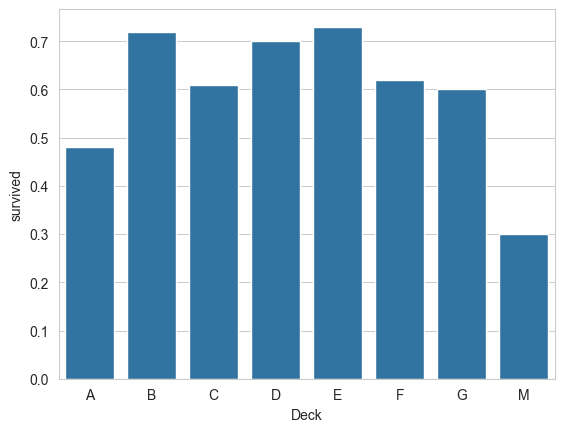

In [34]:
survived = pd.merge(total[['PassengerId','Deck']], y, on='PassengerId').groupby('Deck')['Survived'].mean().round(2).reset_index(name='survived')

sns.barplot(x='Deck', y='survived', data=survived)

In [35]:
total.replace({'Deck':['A','B','C']}, 'ABC', inplace=True)
total.replace({'Deck':['D','E']}, 'DE', inplace=True)
total.replace({'Deck':['F','G']}, 'FG', inplace=True)

In [36]:
total['Deck'].value_counts()

Deck
M      1014
ABC     182
DE       87
FG       26
Name: count, dtype: int64

In [37]:
total.drop(columns='Cabin', axis=1, inplace=True)
print(f"Deck现缺失值:{total['Deck'].isnull().sum()}")

Deck现缺失值:0


### 探索数据分布（Exploratory Data Distribution）

探索数据集中数据的分布，以及训练集中不同特征与生存与否的分布


#### 目标值分布
在训练集上查看目标值的分布：

- 其中生存人数占比38.38% —— **Class 1**
- 没有活下来的人数占比61.62%。—— **Class 0**

Text(0, 0.5, 'Passenger count')

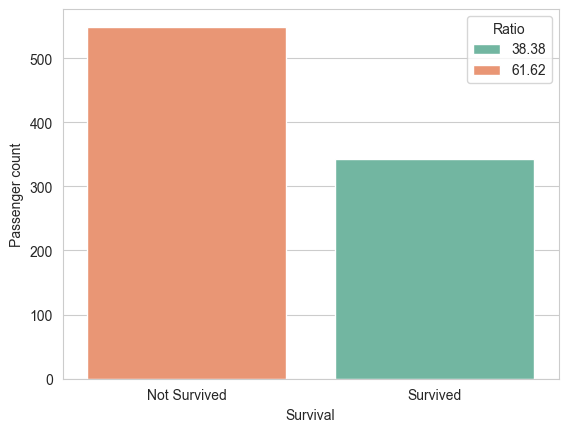

In [38]:
target = y_train['Survived'].value_counts().reset_index(name='count')
target['Ratio'] = round(100*target['count']/target['count'].sum(),2)

fig, ax = plt.subplots()
sns.barplot(data=target, x='Survived', y='count',hue='Ratio',palette='Set2', ax=ax)
ax.set_xticks(range(len(target['Survived'])))
ax.set_xticklabels(['Not Survived', 'Survived'])
ax.set_xlabel('Survival')
ax.set_ylabel('Passenger count')

#### 数值型数据分布

- 连续型数据有：Age, Fare
- 离散型数据有：Sibsp, Parch
- 分类数据：Sex, Pclass, Embarked, Deck

首先查看Age和Fare相对于Survived的数据分布，根据分布可以看出：
- 遇难者的年龄分布的峰度比幸存者的年龄分布要大得多，集中于20到40岁之间，其中30岁左右的人尤其多。20岁以下的人更容易幸存。
- 遇难者的票价分布比幸存者票价分布更加偏斜，集中于低票价区，而高票价区（100左右）的幸存人数更多。从之前的分析中我们也得知，低票价乘客集中于二三等舱，其位置也影响生存概率。


Age中幸存者的年龄分布的峰度:0.23724315667233808
Age中遇难者的年龄分布的峰度:0.9432812651040385


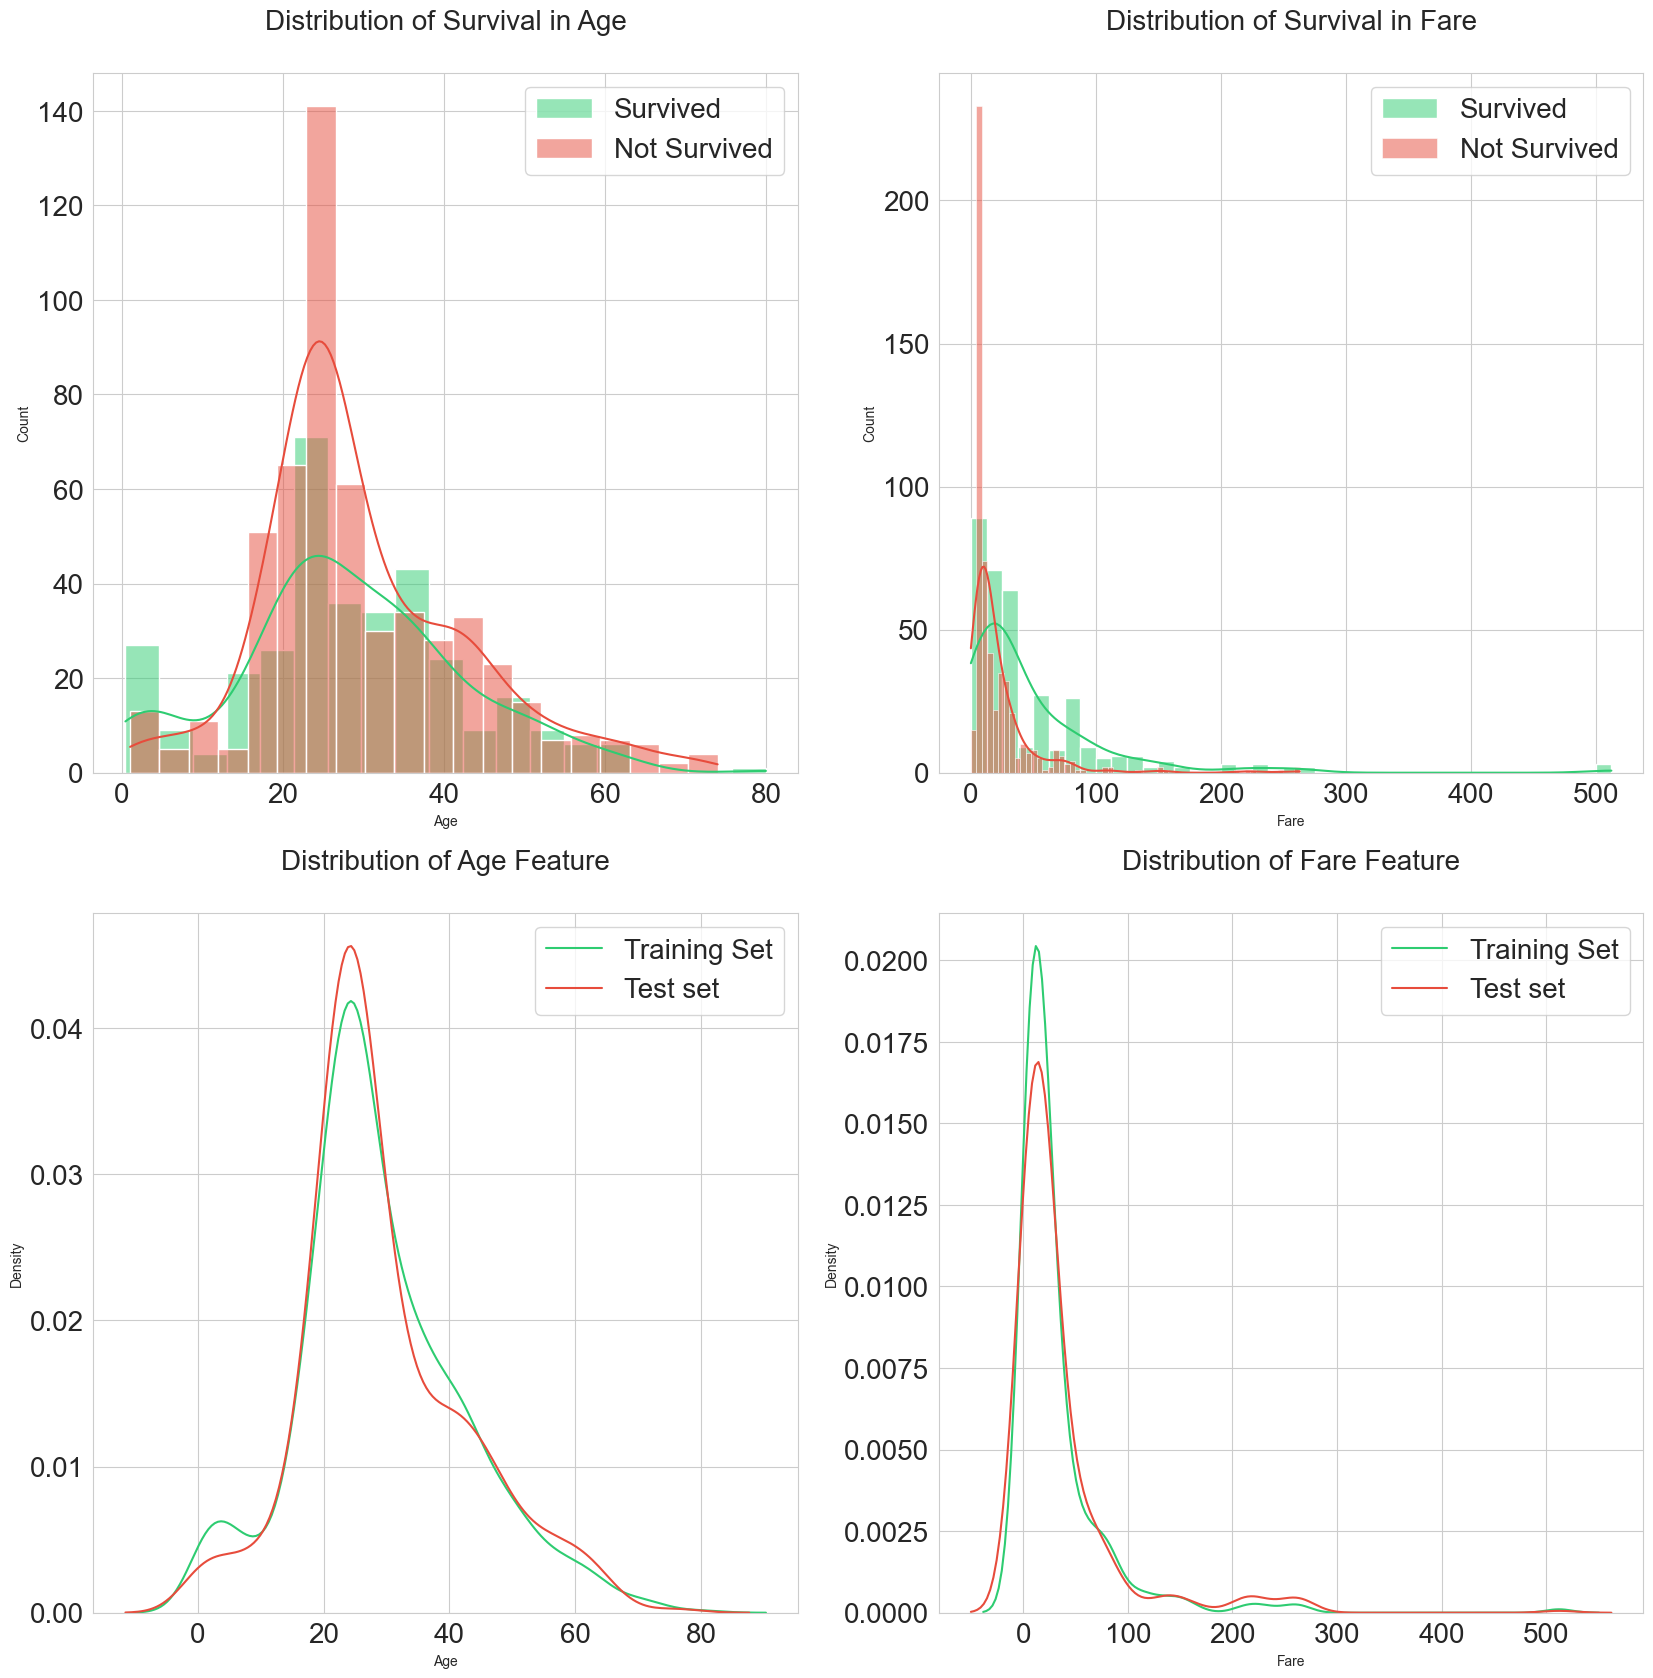

In [39]:
af_train = total[total['PassengerId']<=891][['PassengerId','Age','Fare']]
af_train = pd.merge(af_train, y_train, on='PassengerId')

af_test = total[total['PassengerId']>891][['PassengerId','Age','Fare']]

age_survived_kurt = af_train[af_train['Survived']==1]['Age'].kurtosis()
age_notsurvived_kurt = af_train[af_train['Survived']==0]['Age'].kurtosis()

print(f"Age中幸存者的年龄分布的峰度:{age_survived_kurt}")
print(f"Age中遇难者的年龄分布的峰度:{age_notsurvived_kurt}")

fig, ax = plt.subplots(ncols=2, nrows=2, figsize=(20,20))

flag = af_train['Survived']==1

for i, feature in enumerate(['Age', 'Fare']):
    sns.histplot(af_train[flag][feature], kde=True, label='Survived', color='#2ecc71', ax=ax[0][i])
    sns.histplot(af_train[~flag][feature], kde=True, label='Not Survived', color='#e74c3c', ax=ax[0][i])

    sns.kdeplot(af_train[feature], label='Training Set', color='#2ecc71', ax=ax[1][i])
    sns.kdeplot(af_test[feature],  label='Test set', color='#e74c3c', ax=ax[1][i])

    for j in range(2):
        ax[i][j].tick_params(axis='x', labelsize=20)
        ax[i][j].tick_params(axis='y', labelsize=20)

    ax[0][i].legend(loc='upper right', prop={'size': 20})
    ax[1][i].legend(loc='upper right', prop={'size': 20})

    ax[0][i].set_title('Distribution of Survival in {}'.format(feature), size=20, y=1.05)

    ax[1][0].set_title('Distribution of {} Feature'.format('Age'), size=20, y=1.05)
    ax[1][1].set_title('Distribution of {} Feature'.format('Fare'), size=20, y=1.05)


#### 类别数据分布

类别数据有：Sex, Embarked, Deck, Pclass

除此之外，离散数据的Parch和Sibsp离散值如果较小，也可作为类别数据一起处理。

In [40]:
print(f"Parch所包含的离散数值:{total['Parch'].unique()}")
print(f"Sibsp所包含的离散数值:{total['SibSp'].unique()}")

Parch所包含的离散数值:[0 1 2 5 3 4 6 9]
Sibsp所包含的离散数值:[1 0 3 4 2 5 8]


- 女性生存比例相比男性更高
- 从S港口乘船的人最多，但是从C港口乘船的人的幸存率更高。
- 头等舱的乘客幸存率更高。
- 船上大多数人没有同行的亲人，有同行家人的人中，有一个兄弟姐妹/父母/孩子/配偶的人的幸存比率更高。

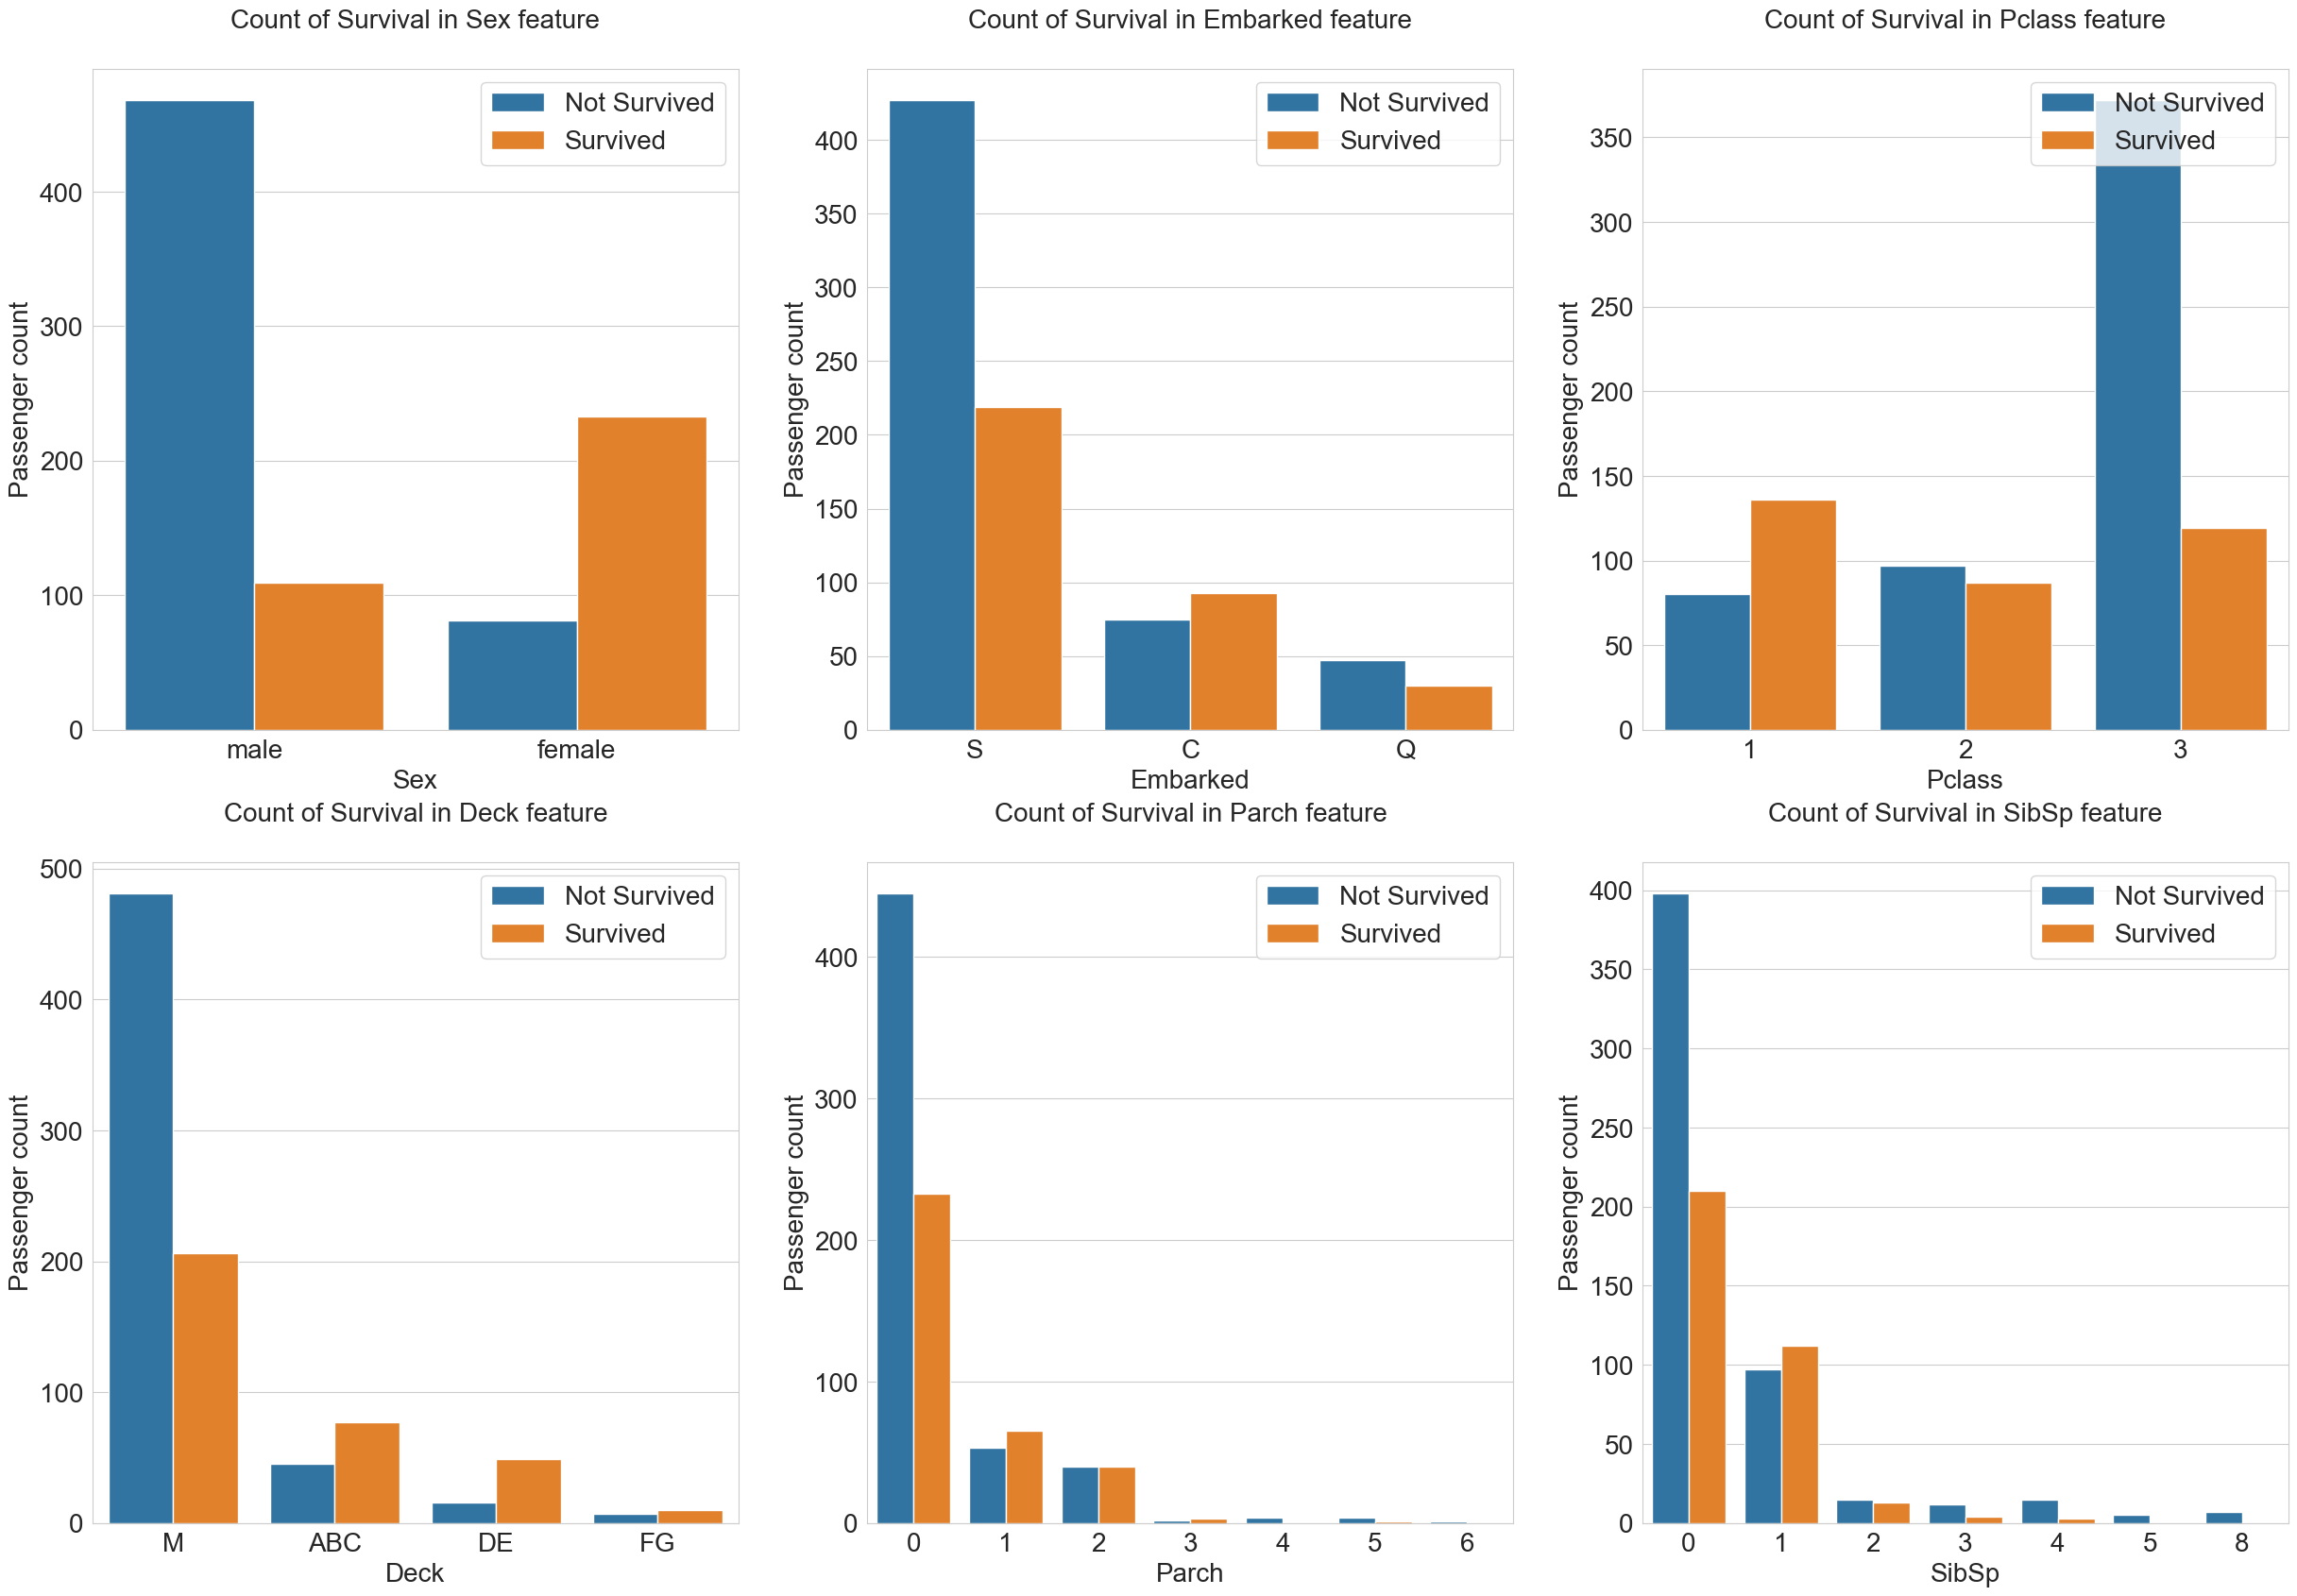

In [41]:

cate = total[total['PassengerId']<=891][['PassengerId','Sex','Embarked','Pclass','Deck','Parch','SibSp']]
cate = pd.merge(cate, y_train, on='PassengerId')

features = ['Sex','Embarked','Pclass','Deck','Parch','SibSp']
flag = cate['Survived']==1

fig, axs = plt.subplots(ncols=3, nrows=2, figsize=(30,20))

for i, feature in enumerate(features):
    plt.subplot(2,3,i+1)
    sns.countplot(data=cate, x=feature, hue='Survived')

    plt.tick_params(axis='x', labelsize=20)
    plt.tick_params(axis='y', labelsize=20)

    plt.xlabel("{}".format(feature), size=20)
    plt.ylabel("Passenger count", size=20)

    plt.legend(['Not Survived','Survived'], loc='upper right', prop={'size': 20})
    plt.title("Count of Survival in {} feature".format(feature), size=20, y=1.05)



### 相关性

筛选出相关性系数>0.1的特征，将特征组合按照相关性的绝对值从大到小排列，忽略正负关系。

- Fare和Pclass的相关性最强烈，推测舱位等级越高，票价越高

In [42]:
corrs = total.corr(numeric_only=True).abs().unstack().reset_index(name='Corr').rename(columns={'level_0':'Feature1','level_1':'Feature2'})
corrs.sort_values(by='Corr', ascending=False, inplace=True)
corrs = corrs[(corrs['Corr']!=1)&(corrs['Corr']>0.1)].reset_index(drop=True)
corrs.drop(index=corrs.iloc[1::2,:].index, inplace=True)
corrs = corrs.reset_index(drop=True)
corrs

,Feature1,Feature2,Corr
0,Fare,Pclass,0.558742
1,Pclass,Age,0.451983
2,Parch,SibSp,0.373587
3,Fare,Parch,0.221668
4,SibSp,Age,0.204025
5,Age,Fare,0.198706
6,Fare,SibSp,0.160389
7,Age,Parch,0.134239


Text(0.5, 1.05, 'Test Set Correlation Matrix')

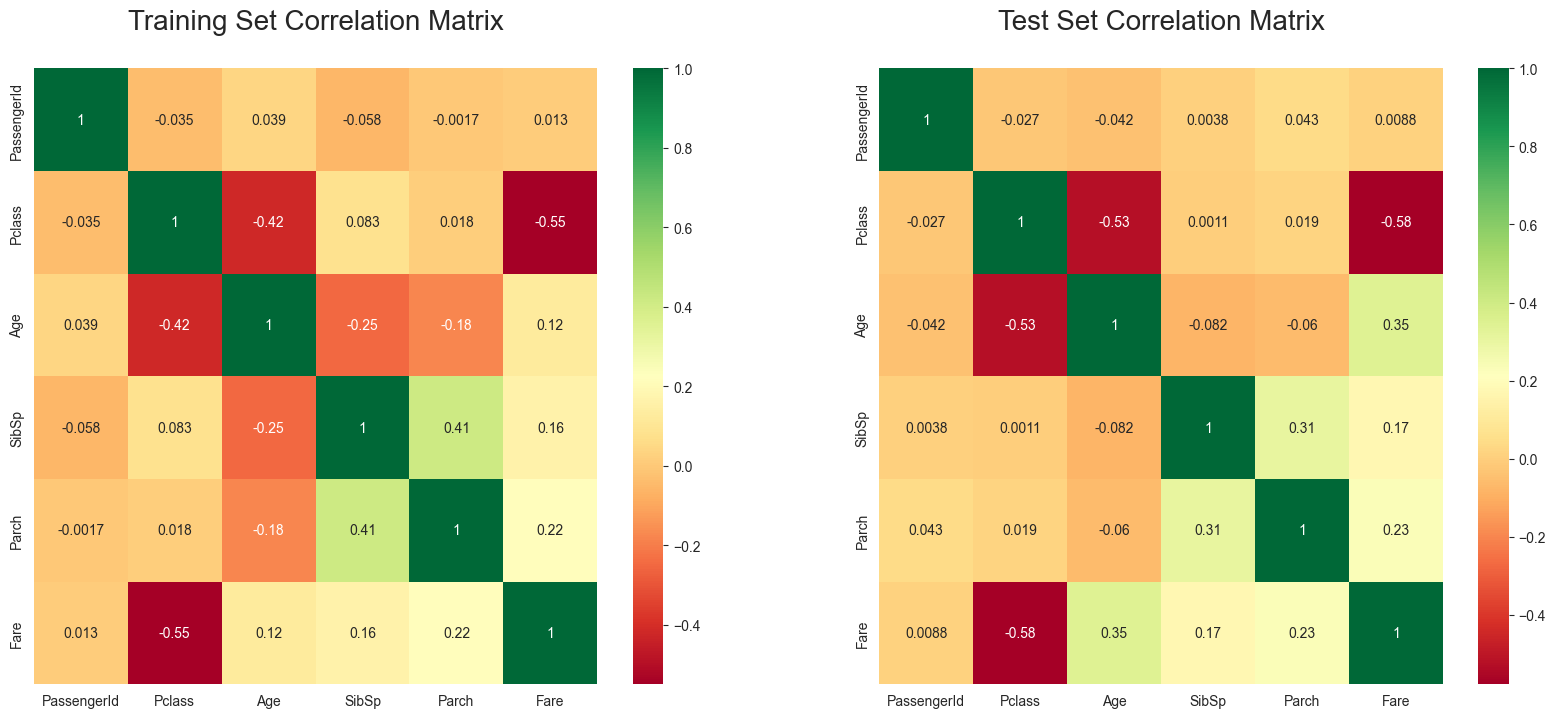

In [43]:
train = total[total['PassengerId']<=891]
test = total[total['PassengerId']>891]

corr_train = train.corr(numeric_only=True)
corr_test = test.corr(numeric_only=True)

fig, axs = plt.subplots(ncols=2, nrows=1, figsize=(20,8))

sns.heatmap(corr_train, annot=True, cmap='RdYlGn', ax=axs[0])
sns.heatmap(corr_test, annot=True, cmap='RdYlGn', ax=axs[1])

axs[0].set_title('Training Set Correlation Matrix', size=20, y=1.05)
axs[1].set_title('Test Set Correlation Matrix', size=20, y=1.05)

## 特征工程（Feature Engineering）

### 连续型数据分箱

#### Age

在探索性数据分析中得到，Age数据较为集中在20岁到40岁之间，但是最小的年龄不满周岁，最大年龄达到80岁左右，因此可以对年龄数据进行分箱，分组查看其与生存率的关系。分箱是利用等规模分箱法。因为年龄分布不均，使用等组距分箱法会导致大多数数据集中在20岁到40岁组，无法有效分析。通过分箱捕捉到，第一组中0到16岁中生存率最高，22岁到25岁生存率最低。

Text(0.5, 1.0, 'Survival Counts in Age Feature')

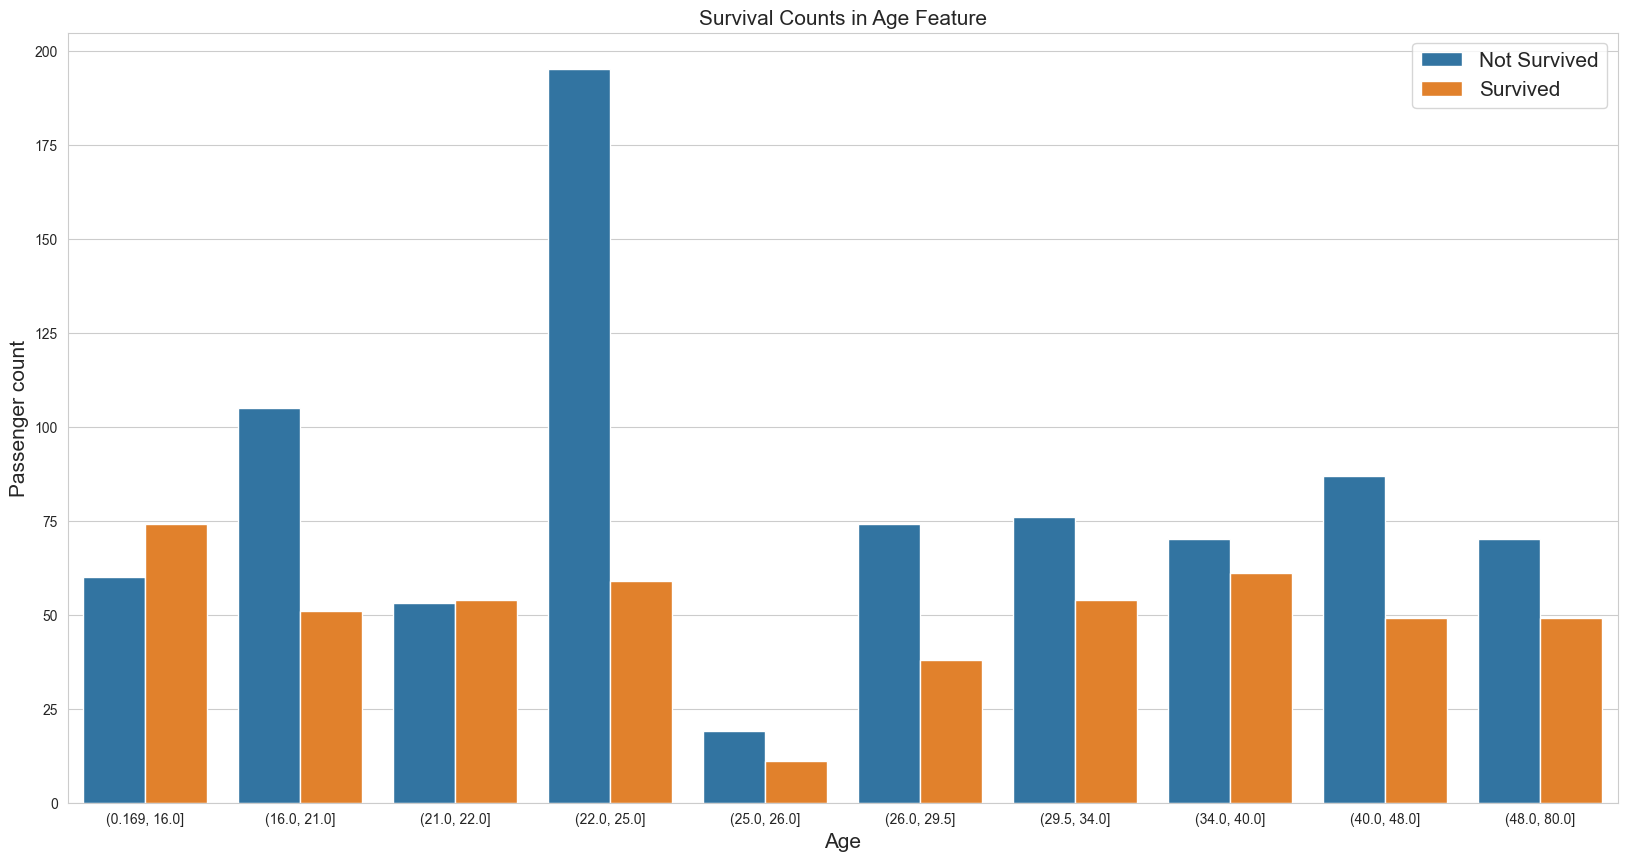

In [44]:
total['Age_group'] = pd.qcut(total['Age'], q=10)
age_group = total[['PassengerId','Age_group']]
age_survive = pd.merge(age_group, y, on='PassengerId')

plt.figure(figsize=(20,10))
sns.countplot(x='Age_group', hue='Survived', data=age_survive)

plt.xlabel("Age", size=15)
plt.ylabel("Passenger count", size=15)

plt.legend(['Not Survived','Survived'], loc='upper right', prop={'size': 15})
plt.title('Survival Counts in Age Feature', size=15)


#### Fare

对票价同样进行等规模分箱，在探索型分析中我们得到，Fare是极度偏斜的，其中Not Survived数据比Survived数据更加偏斜。由箱线图可得，幸存者的中位数票价要比遇难者高，偏度也没有遇难者票价分布大。

[Text(0, 0, 'Not Survived'), Text(1, 0, 'Survived')]

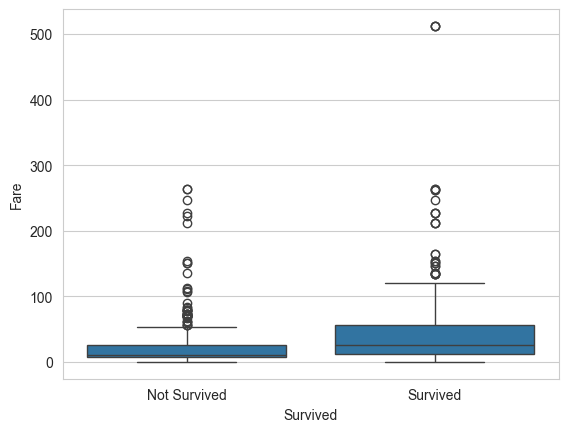

In [45]:
fare = total[['PassengerId','Fare']]
fares = pd.merge(fare, y_train, on='PassengerId')
ax = sns.boxplot(data=fares, x='Survived', y='Fare')
ax.set_xticks(range(2))
ax.set_xticklabels(['Not Survived', 'Survived'])

将Fare进行等规模分箱，分为13组，随着票价的升高，幸存者比率也越来越高，遇难者的比率相对降低。到票价最高档的时候，幸存者比率已经远超过遇难者。一个不太一样的组是(26.82, 41.579]这组，在此组中，遇难者比例仍然较高。

Text(0.5, 1.0, 'Survival Counts in Fare Feature')

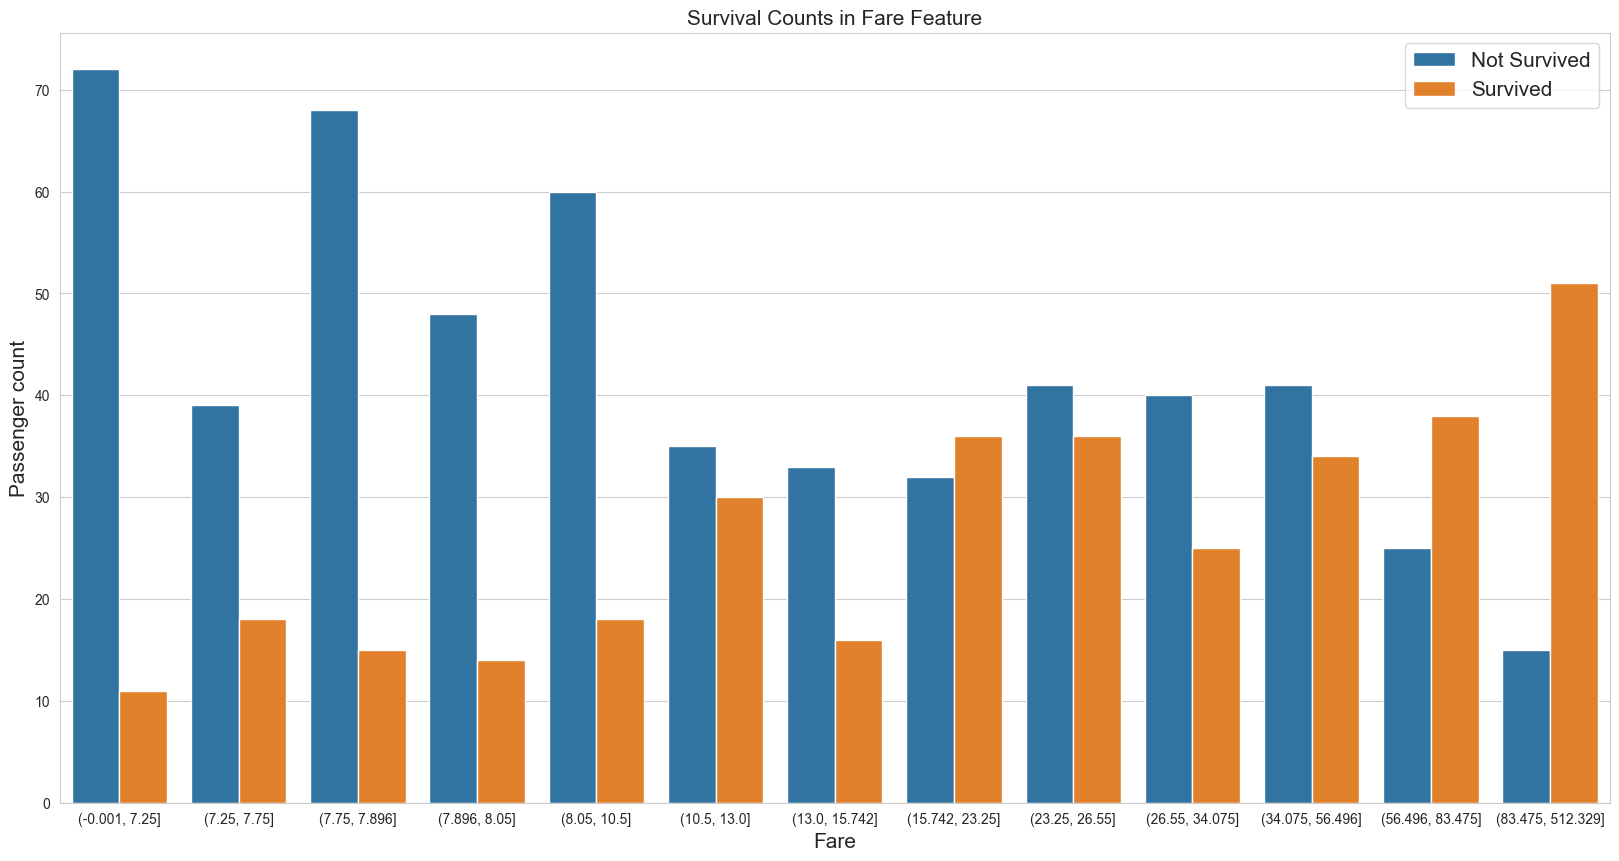

In [46]:
total['Fare_group'] = pd.qcut(total['Fare'], q=13)
fare_group = total[['PassengerId','Fare_group']]
fare_survive = pd.merge(fare_group, y_train, on='PassengerId')

plt.figure(figsize=(20,10))
sns.countplot(data=fare_survive, x='Fare_group', hue='Survived')

plt.xlabel("Fare", size=15)
plt.ylabel("Passenger count", size=15)

plt.legend(['Not Survived','Survived'], loc='upper right', prop={'size': 15})
plt.title("Survival Counts in Fare Feature", size=15)


In [47]:
total.drop(['Age','Fare'], axis=1, inplace=True)
total.rename(columns={'Age_group':'Age', 'Fare_group':'Fare'}, inplace=True)

### 频率编码（Frequency Encoding）

#### Family Size

计算Famliy Size: Family Size = Parch + SibSp +1
- Family Size = 1, 标记为Alone - 说明是独自来的
- Family Size = 2, 3, 4, 标记为Small - 说明家庭规模较小
- Family Size = 5, 6 标记为Medium
- Family Size >=7 标记为 Large

分组后，家庭成员数目较小的组幸存率更高

<Axes: xlabel='FamilySize', ylabel='count'>

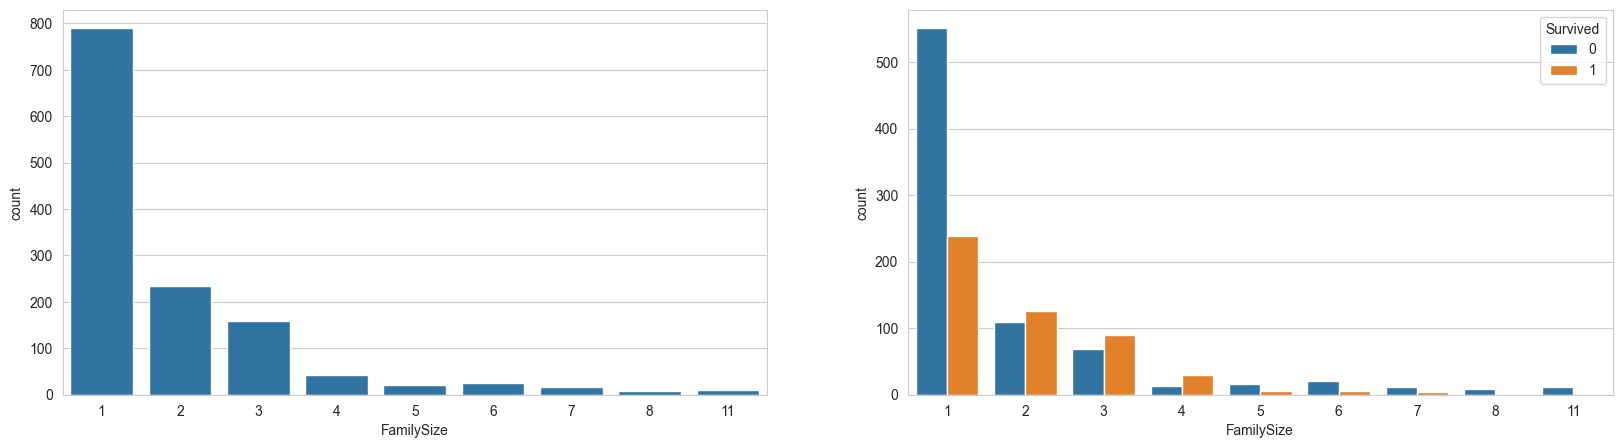

In [48]:
total['FamilySize'] = total['Parch'] + total['SibSp'] + 1
familysize = total['FamilySize'].value_counts().reset_index(name='count')
famliy = total[['PassengerId','FamilySize']]
famliy = pd.merge(famliy, y, on='PassengerId')

fig, ax = plt.subplots(ncols=2, nrows=1, figsize=(20,5))
sns.barplot(data=familysize, x='FamilySize', y='count', ax=ax[0])
sns.countplot(data=famliy, x='FamilySize', hue='Survived',ax=ax[1])

<Axes: xlabel='FamilySizeGroup', ylabel='count'>

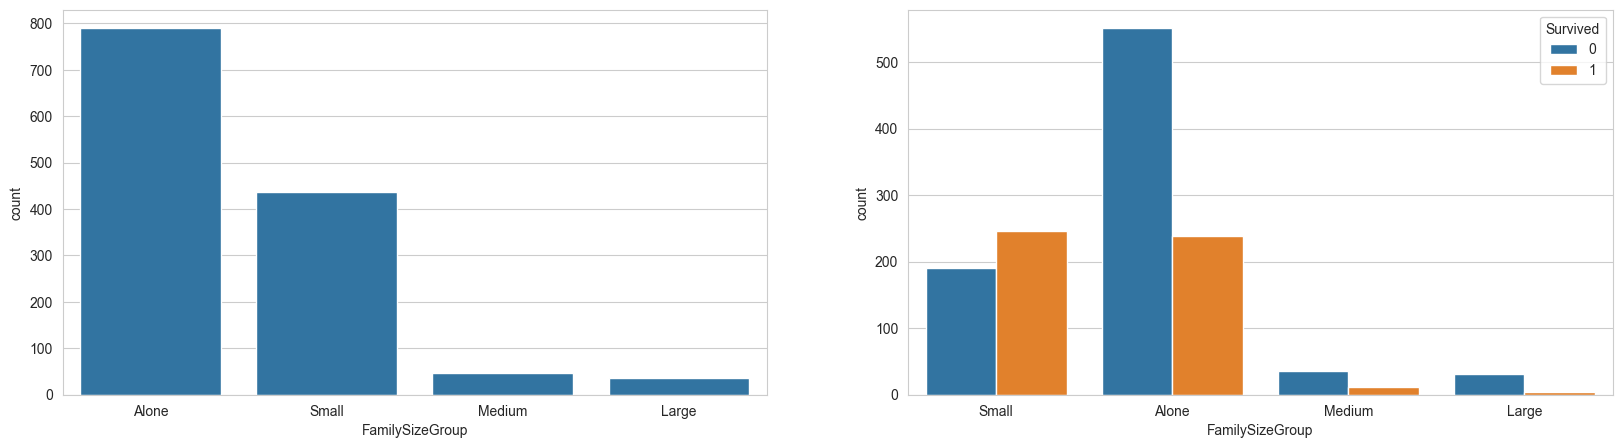

In [49]:
##-----
mapping = {1:'Alone', 2:'Small', 3:'Small', 4:'Small', 5:'Medium', 6:'Medium', 7:'Large', 8:'Large', 11:'Large'}
total['FamilySizeGroup'] = total['FamilySize'].map(mapping)
familygroup = total['FamilySizeGroup'].value_counts().reset_index(name='count')
familygrouped = total[['PassengerId','FamilySizeGroup']]
familygrouped = pd.merge(familygrouped, y, on='PassengerId')

fig, ax = plt.subplots(ncols=2, nrows=1, figsize=(20,5))
sns.barplot(data=familygroup, x='FamilySizeGroup', y='count', ax=ax[0])
sns.countplot(data=familygrouped, x='FamilySizeGroup', hue='Survived',ax=ax[1])

#### Ticket Frequency

Ticket并不是唯一值，其中有很多重复值， 这是因为有很多人购买的团票，这些人可能是一家人，也可能是和朋友一起前来，这些人的车票号码是一样的。我们可以根据车票号码判断哪些人是一起的。通过计算Ticket出现的频率将Ticket进行分组。再对Ticket出现的频率进行分组，就像Family Size一样，计算同行人数量。

Text(0.5, 1.05, 'Count of Survival in Ticket Frequency Feature')

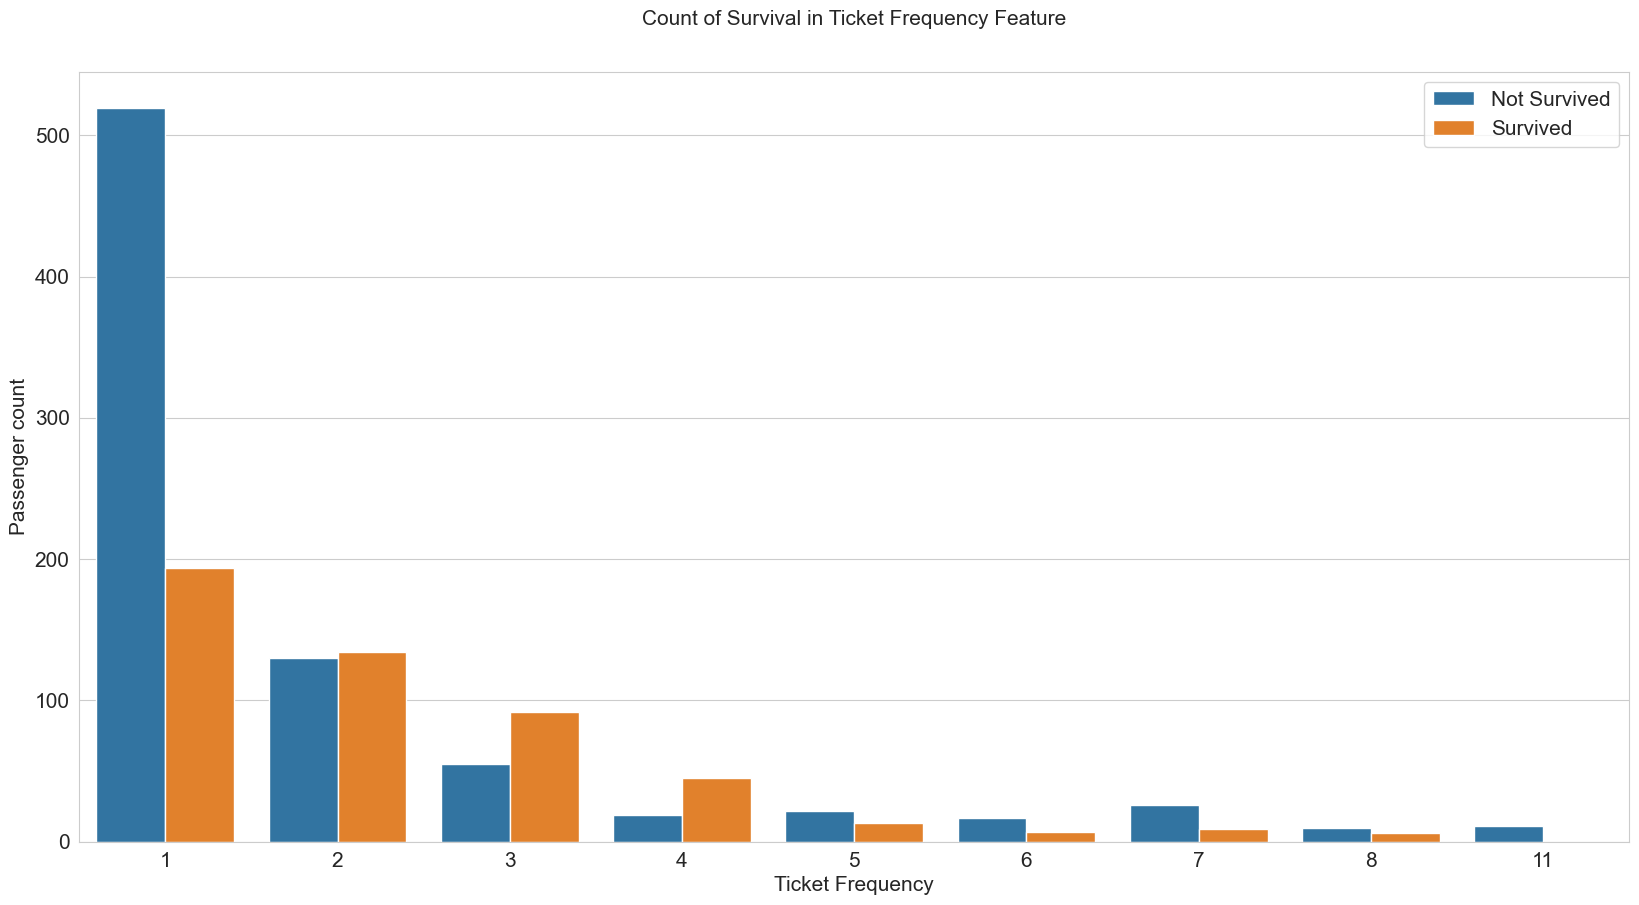

In [50]:
total['Ticket'] = total['Ticket'].astype(str).str.strip()
total['TicketFrequency'] = total.groupby('Ticket')['Ticket'].transform('count')
ticket_fre = total[['PassengerId','TicketFrequency']]
ticket_fre = pd.merge(ticket_fre, y, on='PassengerId')

plt.figure(figsize=(20,10))
sns.countplot(data=ticket_fre, x='TicketFrequency', hue='Survived')
plt.xlabel('Ticket Frequency', size=15)
plt.ylabel('Passenger count', size=15)

plt.legend(['Not Survived','Survived'], prop={'size': 15})

plt.tick_params(axis='x', labelsize=15)
plt.tick_params(axis='y', labelsize=15)

plt.title('Count of Survival in Ticket Frequency Feature', size=15, y=1.05)


### 处理Name- Title

Name的格式常常为XXX, title. ZZZ格式，其中title是一个人的头衔，通常有相应的含义，可以提取出来作为特征。

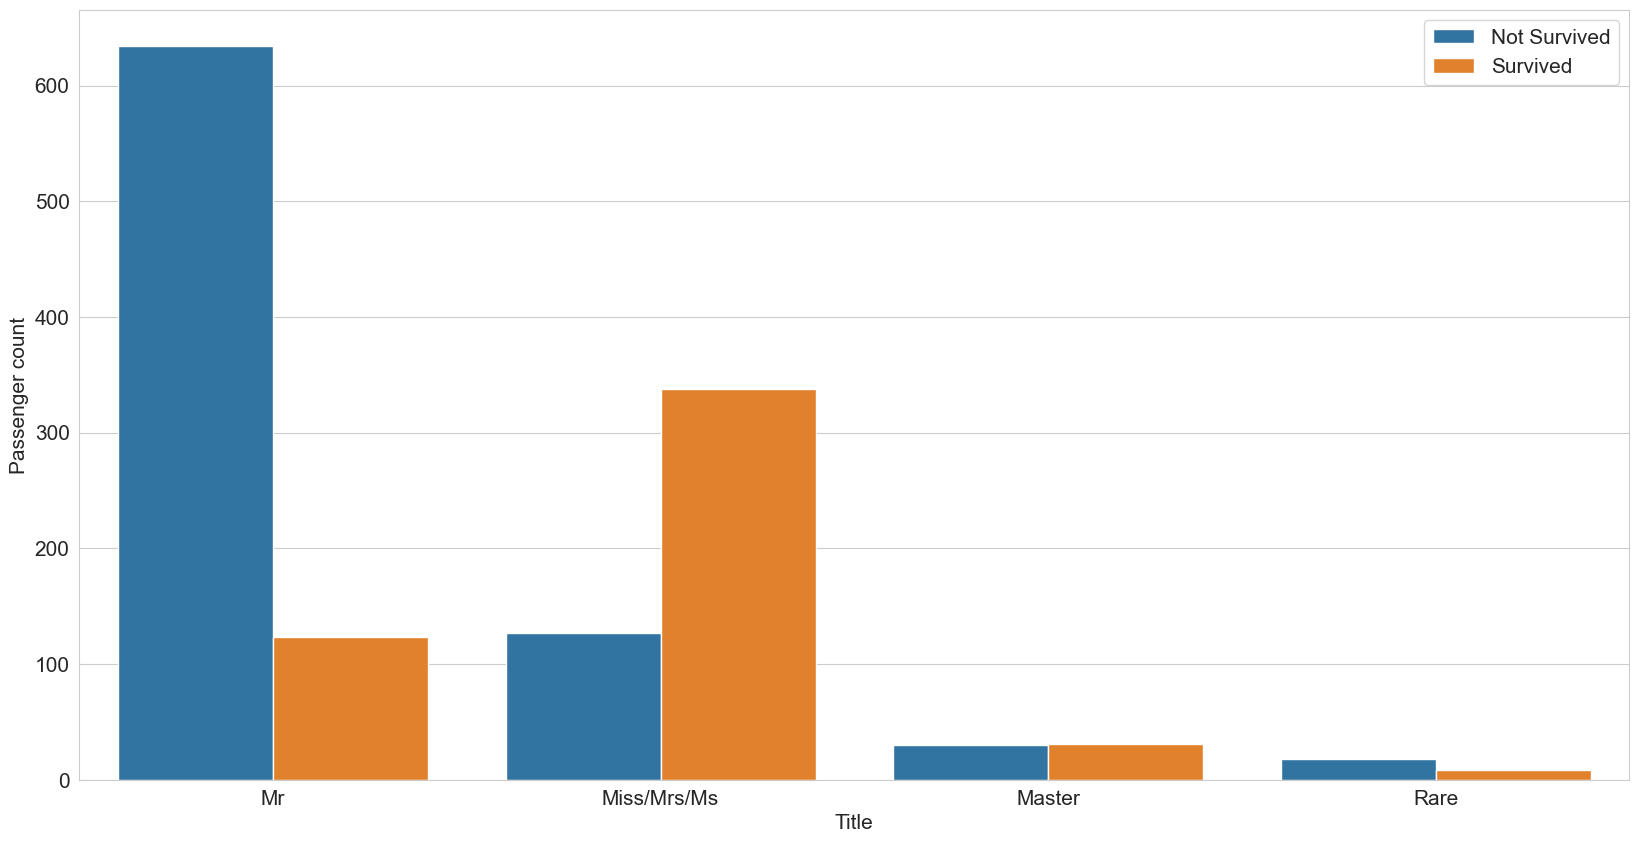

In [51]:
total['Title'] = total['Name'].apply(lambda x: x.split(',')[1].split('.')[0].strip())

# total['IsMarried'] = total['Title'].apply(lambda x:1 if x=='Mrs' else 0)

total['Title'] = total['Title'].replace(['Dona','Mme','Mlle','Ms','Mrs','Miss','Lady','the Countess'], 'Miss/Mrs/Ms')
total['Title'] = total['Title'].replace(['Dr', 'Col', 'Major', 'Jonkheer', 'Capt', 'Sir', 'Don', 'Rev'],'Rare')

title_group = total[['PassengerId','Title']]
title_group = pd.merge(title_group, y, on='PassengerId')

plt.figure(figsize=(20,10))
sns.countplot(data=title_group, x='Title', hue='Survived')

plt.xlabel("Title", size=15)
plt.ylabel("Passenger count", size=15)

plt.legend(['Not Survived','Survived'], loc='upper right', prop={'size': 15})

plt.tick_params(axis='x', labelsize=15)
plt.tick_params(axis='y', labelsize=15)

### Target Encoding



In [52]:
def extract_name(x):
    if '(' in x:
        x = x.split('(')[0]
    fname = x.split(',')[0]
    # fname = fname.replace(r'[^\w\s]', '', regex=True).strip()
    return fname

total['Family'] = total['Name'].apply(lambda x: extract_name(x))
family_count = total['Family'].value_counts().reset_index(name='count')

In [53]:
total['Family'].value_counts()

Family
Andersson    11
Sage         11
Goodwin       8
Asplund       8
Davies        7
             ..
Milling       1
Maisner       1
Goncalves     1
Campbell      1
Saether       1
Name: count, Length: 875, dtype: int64

找出训练/测试都出现的 family/ticket，并将那些成员数大于 1 的组的“生存统计”保存为字典

In [54]:
train_ft = total[total['PassengerId']<=891][['PassengerId','Family','Ticket']]
test_ft = total[total['PassengerId']>891][['PassengerId','Family','Ticket']]
train_ft = pd.merge(train_ft, y, on='PassengerId')

#  1. 找到同时出现在 train 和 test 的 family/ticket
common_families = set(train_ft['Family'].dropna()).intersection(test_ft['Family'].dropna())
common_tickets = set(train_ft['Ticket'].dropna()).intersection(test_ft['Ticket'].dropna())

# 2. 计算每个 family 的生存率（mean）和成员数（size）
family_stats = train_ft.groupby('Family').agg(
    survival_rate=('Survived', 'mean'),
    members=('Survived', 'size')
)

# 过滤：只保留同时出现在 train/test 且成员数 > 1 的 family，并转成字典
family_rates = family_stats.loc[
    family_stats.index.isin(common_families) & (family_stats['members'] > 1),
    'survival_rate'
].to_dict()

# 3. ticket 同理
ticket_stats = train_ft.groupby('Ticket').agg(
    survival_rate=('Survived', 'mean'),
    members=('Survived', 'size')
)

ticket_rates = ticket_stats.loc[
    ticket_stats.index.isin(common_tickets) & (ticket_stats['members'] > 1),
    'survival_rate'
].to_dict()


为训练集和测试集的每一行样本生成新的特征：对应 Family/Ticket 的生存率，以及一个是否缺失的标志位。

1.	生成了 Family_Survival_Rate 和 Ticket_Survival_Rate 作为新特征；
	- 如果 family/ticket 在 train/test 都有且成员数 >1 → 用对应 survival_rate；
	- 否则 → 用全局均值。
2.	生成了两个对应的 缺失标志变量 (NA=0/1)，让模型知道该特征是“真实统计”还是“填充”。

一个额外的二进制特性Family_Survival_Rate_NA是为测试集唯一的家庭创建的。这个特征也是必要的，因为没有办法计算这些家庭的存活率。这一特征意味着，由于无法检索他们的存活率，因此家庭存活率不适用于这些乘客。

In [55]:
# Family
# 计算整体的平均生存率（全体样本存活比例）。
mean_survival_rate = np.mean(train_ft['Survived'])
train_ft['Family_Survival_Rate'] = train_ft['Family'].map(family_rates).fillna(mean_survival_rate)
train_ft['Family_Survival_Rate_NA'] = train_ft['Family'].map(family_rates).notna().astype(int)

test_ft['Family_Survival_Rate'] = test_ft['Family'].map(family_rates).fillna(mean_survival_rate)
test_ft['Family_Survival_Rate_NA'] = test_ft['Family'].map(family_rates).notna().astype(int)

# Ticket
train_ft['Ticket_Survival_Rate'] = train_ft['Ticket'].map(ticket_rates).fillna(mean_survival_rate)
train_ft['Ticket_Survival_Rate_NA'] = train_ft['Ticket'].map(ticket_rates).notna().astype(int)

test_ft['Ticket_Survival_Rate'] = test_ft['Ticket'].map(ticket_rates).fillna(mean_survival_rate)
test_ft['Ticket_Survival_Rate_NA'] = test_ft['Ticket'].map(ticket_rates).notna().astype(int)

In [56]:
for df in [train_ft, test_ft]:
    df['Survival_Rate'] = (df['Ticket_Survival_Rate'] + df['Family_Survival_Rate']) / 2
    df['Survival_Rate_NA'] = (df['Ticket_Survival_Rate_NA'] + df['Family_Survival_Rate_NA']) / 2

In [57]:
ft_total = pd.concat([train_ft.drop('Survived', axis=1), test_ft])
total = pd.merge(total, ft_total, on=['PassengerId','Family','Ticket'])

In [58]:
total.head()

,PassengerId,Pclass,Name,Sex,SibSp,Parch,Ticket,Embarked,Deck,Age,...,FamilySizeGroup,TicketFrequency,Title,Family,Family_Survival_Rate,Family_Survival_Rate_NA,Ticket_Survival_Rate,Ticket_Survival_Rate_NA,Survival_Rate,Survival_Rate_NA
0,1,3,"Braund, Mr. Owen Harris",male,1,0,A/5 21171,S,M,"(21.0, 22.0]",...,Small,1,Mr,Braund,0.383838,0,0.383838,0,0.383838,0.0
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,1,0,PC 17599,C,ABC,"(34.0, 40.0]",...,Small,2,Miss/Mrs/Ms,Cumings,0.383838,0,0.383838,0,0.383838,0.0
2,3,3,"Heikkinen, Miss. Laina",female,0,0,STON/O2. 3101282,S,M,"(25.0, 26.0]",...,Alone,1,Miss/Mrs/Ms,Heikkinen,0.383838,0,0.383838,0,0.383838,0.0
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,1,0,113803,S,ABC,"(34.0, 40.0]",...,Small,2,Miss/Mrs/Ms,Futrelle,0.383838,0,0.383838,0,0.383838,0.0
4,5,3,"Allen, Mr. William Henry",male,0,0,373450,S,M,"(34.0, 40.0]",...,Alone,1,Mr,Allen,0.383838,0,0.383838,0,0.383838,0.0


### 类别变量编码

#### Label Encoding

In [59]:
features = ['Age','Fare','Sex']

for i in features:
    total[i] = LabelEncoder().fit_transform(total[i])

#### One-hot Encoding - 虚拟变量

- 去除一个变量
- 不去除一个变量

In [60]:
features = ['Embarked','Title','Deck','Pclass', 'FamilySizeGroup']

total = pd.get_dummies(total, columns=features, dtype='int',drop_first=True)
total.head()

,PassengerId,Name,Sex,SibSp,Parch,Ticket,Age,Fare,FamilySize,TicketFrequency,...,Title_Mr,Title_Rare,Deck_DE,Deck_FG,Deck_M,Pclass_2,Pclass_3,FamilySizeGroup_Large,FamilySizeGroup_Medium,FamilySizeGroup_Small
0,1,"Braund, Mr. Owen Harris",1,1,0,A/5 21171,2,0,2,1,...,1,0,0,0,1,0,1,0,0,1
1,2,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,1,0,PC 17599,7,11,2,2,...,0,0,0,0,0,0,0,0,0,1
2,3,"Heikkinen, Miss. Laina",0,0,0,STON/O2. 3101282,4,3,1,1,...,0,0,0,0,1,0,1,0,0,0
3,4,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,1,0,113803,7,10,2,2,...,0,0,0,0,0,0,0,0,0,1
4,5,"Allen, Mr. William Henry",1,0,0,373450,7,3,1,1,...,1,0,0,0,1,0,1,0,0,0


In [61]:
drop_cols = ["PassengerId",'Name','SibSp','Parch','Ticket','FamilySize','Ticket_Survival_Rate', 'Family_Survival_Rate', 'Ticket_Survival_Rate_NA', 'Family_Survival_Rate_NA','Family']
total.drop(drop_cols, axis=1, inplace=True)
total.shape

(1309, 19)

In [62]:
total.head()

,Sex,Age,Fare,TicketFrequency,Survival_Rate,Survival_Rate_NA,Embarked_Q,Embarked_S,Title_Miss/Mrs/Ms,Title_Mr,Title_Rare,Deck_DE,Deck_FG,Deck_M,Pclass_2,Pclass_3,FamilySizeGroup_Large,FamilySizeGroup_Medium,FamilySizeGroup_Small
0,1,2,0,1,0.383838,0.0,0,1,0,1,0,0,0,1,0,1,0,0,1
1,0,7,11,2,0.383838,0.0,0,0,1,0,0,0,0,0,0,0,0,0,1
2,0,4,3,1,0.383838,0.0,0,1,1,0,0,0,0,1,0,1,0,0,0
3,0,7,10,2,0.383838,0.0,0,1,1,0,0,0,0,0,0,0,0,0,1
4,1,7,3,1,0.383838,0.0,0,1,0,1,0,0,0,1,0,1,0,0,0


## 划分数据集

In [63]:
X_train = total.iloc[:891, :]
X_test = total.iloc[891:, :]
y_train = y[y['PassengerId']<=891]['Survived']
y_test = y[y['PassengerId']>891]['Survived']

### 数据归一化

In [64]:
scaler = StandardScaler()

features = ['Age', 'Fare', 'TicketFrequency','Survival_Rate','Survival_Rate_NA']

# X_train.loc[:,features] = scaler.fit_transform(X_train.loc[:,features])
# X_test.loc[:,features] = scaler.transform(X_test.loc[:,features])

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## 创建模型

### 基线模型 - 逻辑回归

In [65]:
# 基线模型
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [66]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(model, X_train, y_train, cv=10, scoring='accuracy')
print(f"在训练集上的平均准确率是{scores.mean()}")

在训练集上的平均准确率是0.8462671660424469


In [67]:
y_predict = model.predict(X_test)
accuracy = accuracy_score(y_test, y_predict)
print(f"基线模型-逻辑回归模型的准确率是:{accuracy}")

基线模型-逻辑回归模型的准确率是:0.7607655502392344


#### 网格搜索最佳参数

In [68]:
from sklearn.model_selection import GridSearchCV

lr_param_grid = {'C':[0.01,0.1,0.2,0.5,1,2,5,10],'solver':['liblinear']}

grid = GridSearchCV(LogisticRegression(),param_grid=lr_param_grid, cv=5, scoring='accuracy')

grid.fit(X_train, y_train)
grid.best_estimator_, grid.best_score_, grid.best_params_

(LogisticRegression(C=1, solver='liblinear'),
 0.8473479379825497,
 {'C': 1, 'solver': 'liblinear'})

In [69]:
pred = grid.best_estimator_.predict(X_test)
print(f"最佳Logistic模型的准确率:{accuracy_score(y_test,pred)}")

最佳Logistic模型的准确率:0.7607655502392344


### Random Forest 模型

使用随机森林模型，可以利用交叉验证进行参数选择。

In [70]:
SEED = 42

from sklearn.model_selection import RandomizedSearchCV, GridSearchCV,KFold
#
#
forest_model = RandomForestClassifier(random_state=SEED, oob_score=True,n_jobs=-1, min_samples_leaf=5, min_samples_split=5)
#
param_list = {
    'n_estimators':np.arange(900,1800,100),
    'max_depth': np.arange(3,10)
}
#
grid_search = GridSearchCV(
    estimator=forest_model,
    param_grid=param_list,
    cv=5,
    scoring=['accuracy','f1', 'roc_auc'],
    refit = 'accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

results = grid_search.cv_results_

print(f"最佳参数是:{grid_search.best_params_}")
print(f"最佳分数:{grid_search.best_score_}")


Fitting 5 folds for each of 63 candidates, totalling 315 fits
最佳参数是:{'max_depth': 7, 'n_estimators': 1700}
最佳分数:0.8473291067729585


In [104]:
results = pd.DataFrame(results)

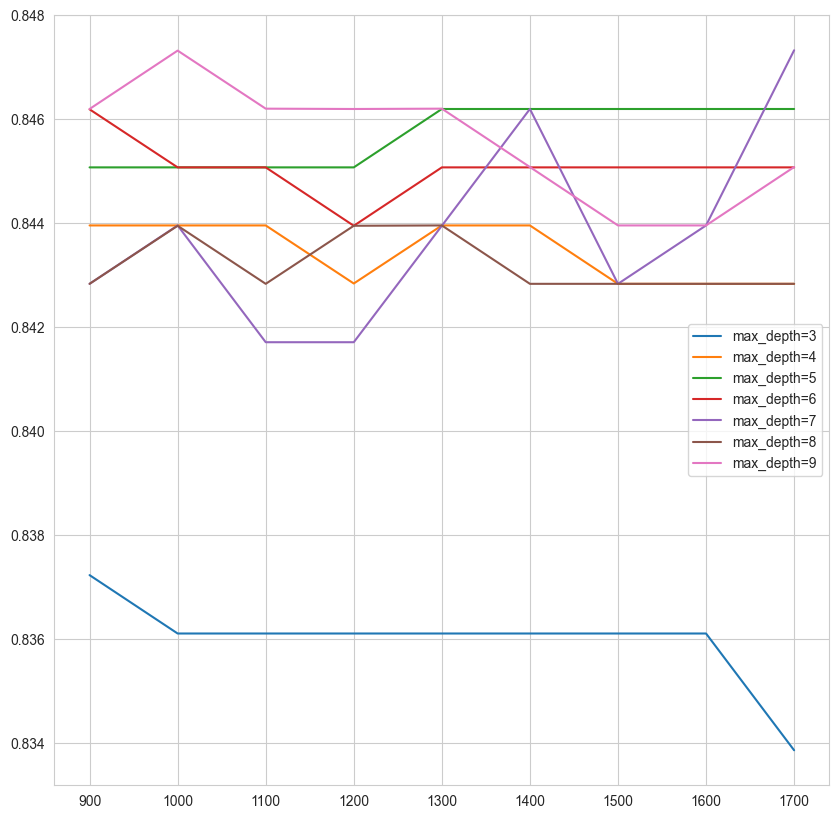

In [105]:
max_depths = [int(i) for i in results['param_max_depth']]
n_estimators = results['param_n_estimators']
fig, ax = plt.subplots(figsize=(10,10))
for max_depth in param_list['max_depth']:
    data = results[results['param_max_depth']==max_depth][['param_n_estimators','mean_test_accuracy']]
    ax.plot(data['param_n_estimators'], data['mean_test_accuracy'], label='max_depth={}'.format(max_depth))
    plt.legend()


In [106]:
for_pred = grid_search.best_estimator_.predict(X_test)
accuracy = accuracy_score(y_test,for_pred)
print(f"最佳模型:{accuracy}")

[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 434 tasks      | elapsed:    0.1s
[Parallel(n_jobs=8)]: Done 784 tasks      | elapsed:    0.1s
[Parallel(n_jobs=8)]: Done 1234 tasks      | elapsed:    0.2s
[Parallel(n_jobs=8)]: Done 1700 out of 1700 | elapsed:    0.2s finished


最佳模型:0.7966507177033493


In [107]:
single_best_model = RandomForestClassifier(criterion='gini',
                                           n_estimators=1000,
                                           max_depth=5,
                                           min_samples_split=5,
                                           min_samples_leaf=5,
                                           oob_score=True,
                                           random_state=SEED,
                                           n_jobs=-1,
                                           verbose=1)
#
leaderboard_model = RandomForestClassifier(criterion='gini',
                                           n_estimators=1500,
                                           max_depth=4,
                                           min_samples_split=6,
                                           min_samples_leaf=6,
                                           oob_score=True,
                                           random_state=SEED,
                                           n_jobs=-1,
                                           verbose=1)

In [108]:
single_best_model.fit(X_train, y_train)
y_pred_single = single_best_model.predict(X_test)
accuracy_single = accuracy_score(y_test, y_pred_single)

leaderboard_model.fit(X_train, y_train)
y_pred = leaderboard_model.predict(X_test)
accuracy_leader = accuracy_score(y_test, y_pred)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 434 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done 784 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:    0.8s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 434 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 784 tasks      | elapsed:    0.1s
[Parallel(n_jobs=8)]: Done 1000 out of 1000 | elapsed:    0.1s finished
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:    0.

In [109]:
print(f"Single Best Model 准确率:{accuracy_single}")
print(f"Leader Board Model 准确率:{accuracy_leader}")

Single Best Model 准确率:0.8014354066985646
Leader Board Model 准确率:0.8038277511961722


In [110]:
submissions = test[['PassengerId']].reset_index(drop=True)
submissions['Survived'] = y_pred
submissions.to_csv("titanic/random_forest_predictions.csv", index=False)

#### StratifiedFold

**为什么使用StratifiedFold?**

StatifiedFold用于交叉验证，评估模型的稳健性，一半情况下使用KFold。但是StratifiedFold是分层K折交叉验证，其保证了每一折中的正负样本比例一一致。

**OOB Score**: 袋外分数， 相当于内置交叉验证的分数，即每折交叉验证的准确率。



In [111]:
# 设置折数为5
N = 5

# 创建分层K折交叉验证实例
skf = StratifiedKFold(n_splits=N, random_state=N, shuffle=True)

oob_scores = [] # 记录OOB score - 袋外分数
scores = [] # 记录AUC分数
test_probs = []  # 记录每一折的预测结果
importances = [] # 记录特征重要性
fpr, tpr, threshholds= [], [], [] #记录specificity和recall

for fold, (trn_idx, val_idx) in enumerate(skf.split(X_train, y_train), start = 1):
    print(f'Fold {fold}:')

    # 创建模型并拟合
    model = leaderboard_model.fit(X_train[trn_idx], y_train[trn_idx])

    # 记录AUC
    # trn_auc = roc_auc_score(y_train[trn_idx], model.predict_proba(X_train[trn_idx])[:,1])
    # val_auc = roc_auc_score(y_train[val_idx], model.predict_proba(X_train[val_idx])[:,1])
    # trn_f,trn_t,trn_thre = roc_curve(y_train[trn_idx], model.predict_proba(X_train[trn_idx])[:,1])
    val_f, val_t, val_thre = roc_curve(y_train[val_idx], model.predict_proba(X_train[val_idx])[:,1])
    val_pred = model.predict(X_train[val_idx])

    # trn_auc = auc(trn_f, trn_t)
    val_auc = auc(val_f, val_t)

    tpr.append(val_t)
    fpr.append(val_f)
    scores.append(val_auc)
    threshholds.append(val_thre)

    # 记录预测结果
    test_probs.append(model.predict_proba(X_test))

    # 记录特征重要性
    importances.append(model.feature_importances_)

    # 记录oob_scores
    # hasattr 作用：检查一个对象是否有某种属性
    if hasattr(model, 'oob_score_'):
        oob_scores.append(model.oob_score_)
        print(f"Fold {fold} OOB Score: {model.oob_score_}")

    print(classification_report(y_train[val_idx], val_pred))

print(f"Average OOB Score: {np.mean(oob_scores)}")

Fold 1:


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 434 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Done 784 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-1)]: Done 1234 tasks      | elapsed:    0.7s
[Parallel(n_jobs=-1)]: Done 1500 out of 1500 | elapsed:    0.9s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 434 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 784 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 1234 tasks      | elapsed:    0.1s
[Parallel(n_jobs=8)]: Done 1500 out of 1500 | elapsed:    0.1s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent worker

Fold 1 OOB Score: 0.8525280898876404
              precision    recall  f1-score   support

           0       0.84      0.85      0.85       110
           1       0.76      0.74      0.75        69

    accuracy                           0.81       179
   macro avg       0.80      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179

Fold 2:


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 434 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Done 784 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-1)]: Done 1234 tasks      | elapsed:    0.8s
[Parallel(n_jobs=-1)]: Done 1500 out of 1500 | elapsed:    0.9s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 434 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 784 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 1234 tasks      | elapsed:    0.1s
[Parallel(n_jobs=8)]: Done 1500 out of 1500 | elapsed:    0.1s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent worker

Fold 2 OOB Score: 0.8457223001402524
              precision    recall  f1-score   support

           0       0.84      0.89      0.86       110
           1       0.80      0.72      0.76        68

    accuracy                           0.83       178
   macro avg       0.82      0.81      0.81       178
weighted avg       0.82      0.83      0.82       178

Fold 3:


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 434 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Done 784 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-1)]: Done 1234 tasks      | elapsed:    0.8s
[Parallel(n_jobs=-1)]: Done 1500 out of 1500 | elapsed:    1.0s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 434 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 784 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 1234 tasks      | elapsed:    0.1s
[Parallel(n_jobs=8)]: Done 1500 out of 1500 | elapsed:    0.1s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent worker

Fold 3 OOB Score: 0.8513323983169705
              precision    recall  f1-score   support

           0       0.79      0.94      0.86       110
           1       0.85      0.60      0.71        68

    accuracy                           0.81       178
   macro avg       0.82      0.77      0.78       178
weighted avg       0.82      0.81      0.80       178

Fold 4:


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 434 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Done 784 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-1)]: Done 1234 tasks      | elapsed:    0.8s
[Parallel(n_jobs=-1)]: Done 1500 out of 1500 | elapsed:    1.0s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 434 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 784 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 1234 tasks      | elapsed:    0.1s
[Parallel(n_jobs=8)]: Done 1500 out of 1500 | elapsed:    0.1s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent worker

Fold 4 OOB Score: 0.8330995792426368
              precision    recall  f1-score   support

           0       0.89      0.93      0.91       110
           1       0.87      0.81      0.84        68

    accuracy                           0.88       178
   macro avg       0.88      0.87      0.87       178
weighted avg       0.88      0.88      0.88       178

Fold 5:


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 434 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Done 784 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-1)]: Done 1234 tasks      | elapsed:    0.8s
[Parallel(n_jobs=-1)]: Done 1500 out of 1500 | elapsed:    1.0s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 434 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 784 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 1234 tasks      | elapsed:    0.1s
[Parallel(n_jobs=8)]: Done 1500 out of 1500 | elapsed:    0.1s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent worker

Fold 5 OOB Score: 0.8302945301542777
              precision    recall  f1-score   support

           0       0.89      0.94      0.91       109
           1       0.89      0.81      0.85        69

    accuracy                           0.89       178
   macro avg       0.89      0.87      0.88       178
weighted avg       0.89      0.89      0.89       178

Average OOB Score: 0.8425953795483554


[Parallel(n_jobs=8)]: Done 784 tasks      | elapsed:    0.1s
[Parallel(n_jobs=8)]: Done 1234 tasks      | elapsed:    0.1s
[Parallel(n_jobs=8)]: Done 1500 out of 1500 | elapsed:    0.1s finished


#### 特征重要性

/var/folders/vp/8_rd4_c56g3dpqb1167z6tqr0000gn/T/ipykernel_2426/2317733447.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=fimportance, x='Importance', y='Feature', palette='hls')


Text(0.5, 1.0, 'Feature Importances')

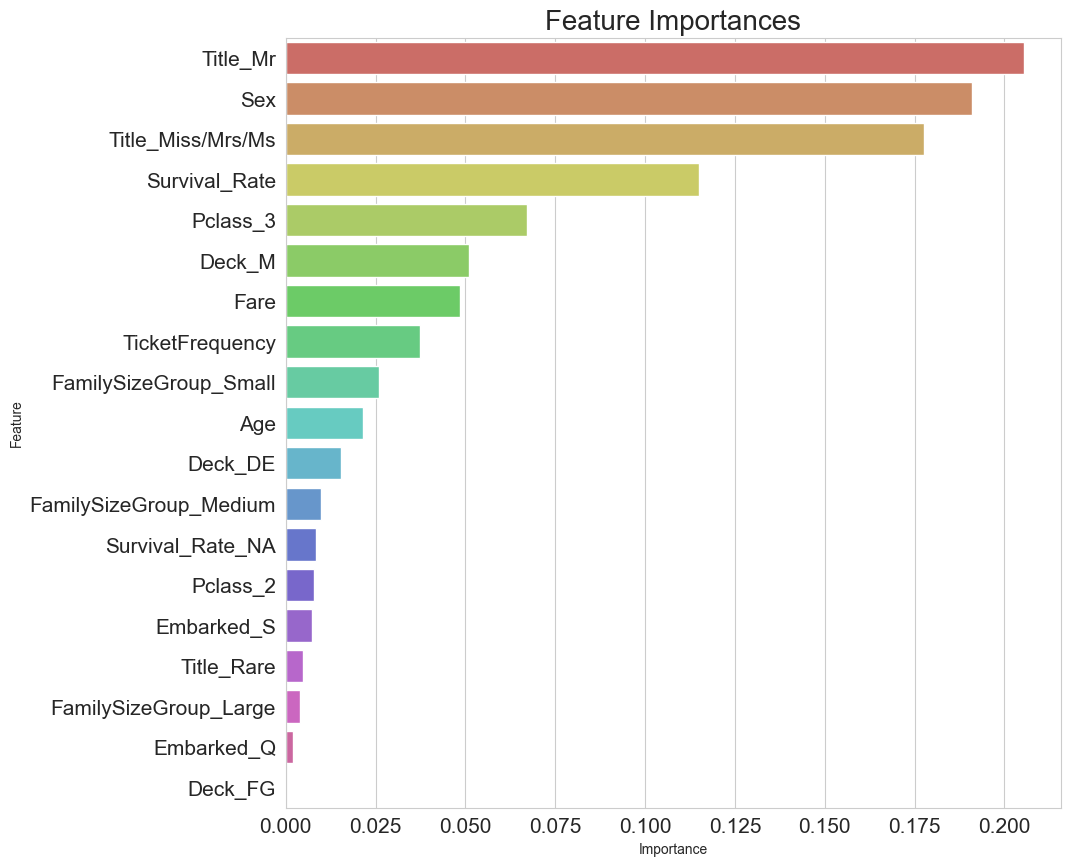

In [112]:
importances = np.array(importances)
fimportance = pd.DataFrame(data=importances,columns=total.columns).T
fimportance = fimportance.mean(axis=1).reset_index(name='Importance')
fimportance.rename(columns={"index":"Feature"}, inplace=True)
fimportance.sort_values(by='Importance', ascending=False, inplace=True)

plt.figure(figsize = (10,10))
sns.barplot(data=fimportance, x='Importance', y='Feature', palette='hls')
plt.tick_params(axis='x', labelsize=15)
plt.tick_params(axis='y', labelsize=15)
plt.title('Feature Importances', size=20)

#### ROC Curve

根据交叉验证得到的阈值、假阳率、真阳率，绘制ROC曲线，其中包括每一折ROC曲线，平均ROC曲线和曲线的置信区间

- mean_tpr + std_tpr 与 mean_tpr - std_tpr 分别是“平均 TPR 的上界/下界（±1 标准差）”。
- TPR 是概率值，理论上应限制在 [0,1]。为了保证界在合法区间，需要把上界 不超过 1、下界 不低于 0。
- minimum(a, b)：对 a 与 b 做逐元素比较并取最小值，返回与 a 形状相同的数组。

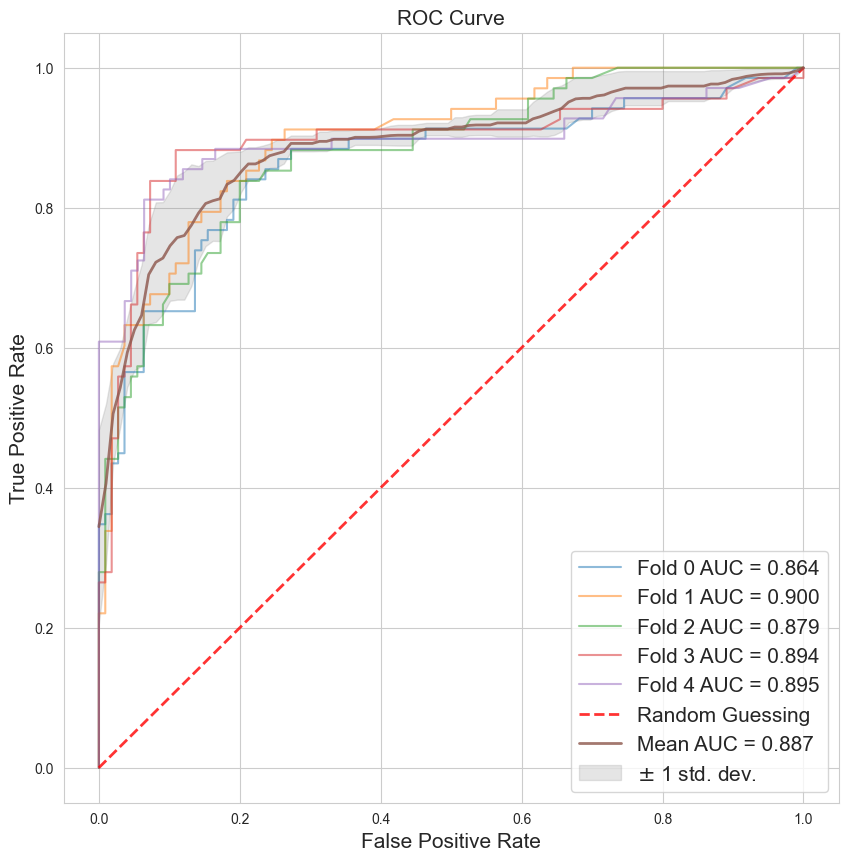

In [113]:
fpr_mean = np.linspace(0,1,100)  # 定义一个 0 到 1 的等距网格，100 个点，用于后面插值
tpr_inter = []  # 用来存储插值后的 TPR（为了对齐不同折的 FPR）。
aucs = scores # 每一折下AUC值

fig, ax = plt.subplots(figsize = (10,10))

for fold, (f, t) in enumerate(zip(fpr,tpr)):
    tpr_inter.append(np.interp(fpr_mean, f,t))  # 用 np.interp 在 fpr_mean 上对 tpr 进行插值，这样不同折的曲线就可以对齐，便于平均。
    ax.plot(f, t, alpha=0.5, label=f'Fold {fold} AUC = {aucs[fold]:.3f}')

#  画随机猜测基准线
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r', alpha=0.8, label='Random Guessing')

# 画平均ROC曲线
tpr_mean = np.mean(tpr_inter, axis=0)
auc_mean = np.mean(aucs)
auc_std = np.std(aucs)

plt.plot(fpr_mean, tpr_mean,lw=2, alpha=0.8, label=f'Mean AUC = {auc_mean:.3f}')

# 画标准差带
std_tpr = np.std(tpr_inter, axis=0)
tpr_upper = np.minimum(tpr_mean+std_tpr,1)
tpr_lower = np.maximum(tpr_mean-std_tpr, 0)
ax.fill_between(fpr_mean, tpr_lower, tpr_upper, alpha=0.2, color='grey', label='$\pm$ 1 std. dev.')

ax.set_xlabel('False Positive Rate', fontsize=15)
ax.set_ylabel('True Positive Rate', fontsize=15)
ax.set_title("ROC Curve", fontsize=15)
ax.legend(loc="lower right", fontsize=15)

#### OUTPUT

In [114]:
test_probs = np.array(test_probs)
probs = test_probs[0]
for i in range(1,test_probs.shape[0]):
    probs = np.concatenate((probs, test_probs[i]), axis=1)

prob_1 = np.mean(probs[:,1::2],axis=1)
prob_0 = np.mean(probs[:,::2],axis=1)

probs = pd.DataFrame({0: prob_0, 1:prob_1})

accs = []
threshs = np.linspace(0,1,100)
for i in threshs:
    probs['pred'] = probs.apply(lambda x: 1 if x[1]>i else 0, axis=1)

    y_pred = probs['pred']

    accuracy = accuracy_score(y_test, y_pred)

    accs.append(accuracy)

max_thresh = threshs[np.argmax(accs)]

probs['pred'] = probs.apply(lambda x: 1 if x[1]>0.5 else 0, axis=1)

y_pred_1 = probs['pred']

accuracy = accuracy_score(y_test, y_pred_1)
print(f"交叉验证后模型准确率:{accuracy}")
print(f"最佳阈值:{max_thresh}")
print(classification_report(y_test, y_pred_1))

交叉验证后模型准确率:0.8014354066985646
最佳阈值:0.494949494949495
              precision    recall  f1-score   support

           0       0.83      0.85      0.84       260
           1       0.75      0.72      0.73       158

    accuracy                           0.80       418
   macro avg       0.79      0.78      0.79       418
weighted avg       0.80      0.80      0.80       418

